# The Fama–French Three-Factor Model — Construction, Diagnostics and Evidence

**A 15-year study on 500+ US equities**

---

## What this notebook does

This is a complete, end-to-end empirical study of the Fama–French (1993) three-factor
model. It is deliberately *not* a code demo: the goal is to build the model, state its
assumptions precisely, interrogate its residuals, and then present real evidence about
whether it works — including evidence about where it fails.

The notebook is organised as an argument in six steps:

| Step | Question | Where |
|---|---|---|
| 1 | Where does the model come from, and why these three factors? | §2 |
| 2 | What data do we need, and what biases does it carry? | §3 |
| 3 | What does a single regression actually tell us? | §5 |
| 4 | Do the OLS assumptions hold, and what breaks if they don't? | §6 |
| 5 | Does the model *explain* returns better than the CAPM? | §7 |
| 6 | Does the model *price* assets it has never seen? | §8–§10 |

**Headline design choices**

* **Universe** — every current S&P 500 + S&P MidCap 400 + Nasdaq-100 + Dow constituent
  with sufficient history (typically 550–750 names, comfortably above the 500 required).
  Mid-caps are included on purpose: a pure large-cap universe gives SMB nothing to explain.
* **Sample** — 15 years of monthly returns for the evaluation window, preceded by a
  7-year burn-in so that *every* evaluation month has a genuine out-of-sample beta.
* **Re-estimation frequency** — **60-month rolling windows, updated every month.**
  This is the dominant convention in both the academic literature (Fama–MacBeth 1973;
  Fama–French 1992) and in industry risk systems. §9 explains why, and shows what
  happens at 36 and 120 months.
* **Factors** — taken from the Kenneth R. French Data Library rather than rebuilt.
  Rebuilding them properly requires point-in-time Compustat data with the correct
  accounting-lag conventions; using French's own series also makes every number here
  directly comparable to the published literature.
* **Inference** — Newey–West HAC standard errors everywhere, plus the Gibbons–Ross–Shanken
  (1989) *F*-test, Fama–MacBeth cross-sectional regressions, and a placebo experiment.

**Runtime.** The first run downloads ~900 tickers of daily data from Yahoo Finance and
takes roughly 4–10 minutes. Everything is cached to `./data_cache`, so re-runs take
seconds. Run the cells in order, top to bottom.

---
# 1. Setup

In [1]:
# ============================================================================
#  0.1  Environment bootstrap
# ----------------------------------------------------------------------------
#  Set AUTO_INSTALL = False if you prefer to manage your own environment.
#  Manual equivalent:
#      pip install numpy pandas scipy matplotlib statsmodels yfinance requests lxml
# ============================================================================
AUTO_INSTALL = True

import importlib.util, subprocess, sys

REQUIRED = {          # import-name -> pip-name
    "numpy": "numpy", "pandas": "pandas", "scipy": "scipy",
    "matplotlib": "matplotlib", "statsmodels": "statsmodels",
    "yfinance": "yfinance", "requests": "requests", "lxml": "lxml",
}
missing = [pip for mod, pip in REQUIRED.items() if importlib.util.find_spec(mod) is None]

if missing:
    if AUTO_INSTALL:
        print("Installing missing packages:", ", ".join(missing))
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
        print("Done.")
    else:
        raise ImportError("Missing packages: " + ", ".join(missing))
else:
    print("All required packages already present.")

All required packages already present.


In [2]:
# ============================================================================
#  0.2  Imports, global configuration and plotting style
# ============================================================================
import io, os, sys, time, zipfile, warnings, itertools
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import scipy.stats as st
from scipy.stats import f as f_dist

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

import statsmodels.api as sm
from statsmodels.stats.stattools import jarque_bera, durbin_watson
from statsmodels.stats.diagnostic import (acorr_ljungbox, het_breuschpagan,
                                          het_white, het_arch, acorr_breusch_godfrey)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.multitest import multipletests

import yfinance as yf
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
np.random.seed(42)

# ---- pandas version compatibility (month-end alias changed in pandas 2.2) ---
def _month_end_alias():
    for alias in ("ME", "M"):
        try:
            pd.tseries.frequencies.to_offset(alias)
            return alias
        except Exception:
            continue
    return "M"

ME = _month_end_alias()


def month_end_index(idx):
    """Normalise any date-like index to unambiguous month-end midnight stamps,
    so Yahoo months and Ken French months line up exactly."""
    p = idx if isinstance(idx, pd.PeriodIndex) else pd.DatetimeIndex(idx).to_period("M")
    return p.to_timestamp(how="end").normalize()

# ---------------------------------------------------------------- config ---
CFG = dict(
    EVAL_YEARS        = 15,    # length of the evaluation window requested
    BURN_IN_YEARS     = 7,     # 5y for the first rolling window + 2y so that an
                               # annual (June) portfolio formation date always exists
    EST_WINDOW        = 60,    # months in each rolling estimation window
    MIN_OBS_IN_WINDOW = 48,    # min non-missing months to accept a window
    N_QUANTILES       = 5,     # 5x5 = 25 test portfolios
    MIN_STOCK_MONTHS  = 120,   # min monthly observations to keep a stock
    TARGET_UNIVERSE   = 500,   # hard requirement from the brief
)

CACHE = Path("./data_cache"); CACHE.mkdir(exist_ok=True)
FIGDIR = Path("./figures");   FIGDIR.mkdir(exist_ok=True)

# End of sample = last complete calendar month.
_today   = pd.Timestamp.today().normalize()
END_DATE = (_today.replace(day=1) - pd.Timedelta(days=1))
EVAL_START = (END_DATE - pd.DateOffset(years=CFG["EVAL_YEARS"])).replace(day=1)
DATA_START = (EVAL_START - pd.DateOffset(years=CFG["BURN_IN_YEARS"])).replace(day=1)

print(f"Download window : {DATA_START:%Y-%m-%d}  ->  {END_DATE:%Y-%m-%d}"
      f"   ({CFG['EVAL_YEARS'] + CFG['BURN_IN_YEARS']} years)")
print(f"Evaluation window: {EVAL_START:%Y-%m-%d}  ->  {END_DATE:%Y-%m-%d}"
      f"   ({CFG['EVAL_YEARS']} years, as requested)")
print(f"The first {CFG['BURN_IN_YEARS']} years are burn-in: they are consumed by the "
      f"{CFG['EST_WINDOW']}-month rolling window so that\nevery month of the 15-year "
      f"evaluation window has a genuine out-of-sample beta estimate.")

# ---------------------------------------------------------------- styling --
mpl.rcParams.update({
    "figure.figsize": (13, 5.5), "figure.dpi": 110, "savefig.dpi": 150,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linestyle": "-",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 12.5, "axes.titleweight": "bold", "axes.labelsize": 10.5,
    "legend.frameon": False, "legend.fontsize": 9.5,
    "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
    "font.family": "DejaVu Sans",
})

PALETTE = {
    "Mkt-RF": "#1f3b73", "SMB": "#c1440e", "HML": "#2a7f62",
    "RMW":    "#7b3f9d", "CMA": "#b58900", "MOM": "#4f4f4f", "RF": "#8a8a8a",
}
PCT = FuncFormatter(lambda v, _: f"{v:,.0%}")
print("\nSetup complete.")

Download window : 2004-07-01  ->  2026-07-31   (22 years)
Evaluation window: 2011-07-01  ->  2026-07-31   (15 years, as requested)
The first 7 years are burn-in: they are consumed by the 60-month rolling window so that
every month of the 15-year evaluation window has a genuine out-of-sample beta estimate.

Setup complete.


In [3]:
# ============================================================================
#  0.3  Econometrics toolkit
#  Everything statistical used later in the notebook is defined here once, so
#  the analysis cells stay readable and every test is applied consistently.
# ============================================================================

# ---------------------------------------------------------------------------
#  Newey-West lag rule of thumb, Newey & West (1994):  L = floor(4*(T/100)^(2/9))
# ---------------------------------------------------------------------------
def nw_lags(T: int) -> int:
    return int(max(1, np.floor(4.0 * (T / 100.0) ** (2.0 / 9.0))))


def ols(y, X, hac: bool = True, lags: int | None = None):
    """OLS of y on X (constant added automatically). Returns a fitted
    statsmodels result. HAC = Newey-West heteroskedasticity- and
    autocorrelation-consistent covariance (the default for return regressions)."""
    y = pd.Series(y).astype(float)
    X = pd.DataFrame(X).astype(float)
    X = sm.add_constant(X, has_constant="add")
    idx = y.index.intersection(X.index)
    y, X = y.loc[idx], X.loc[idx]
    ok = y.notna() & X.notna().all(axis=1)
    y, X = y[ok], X[ok]
    model = sm.OLS(y, X)
    if hac:
        L = lags if lags is not None else nw_lags(len(y))
        return model.fit(cov_type="HAC", cov_kwds={"maxlags": L, "use_correction": True})
    return model.fit()


def nw_mean_tstat(s):
    """Mean of a series with a Newey-West standard error and t-statistic.
    (Regressing the series on a constant with HAC errors.)"""
    s = pd.Series(s).dropna().astype(float)
    if len(s) < 6:
        return float(s.mean()), np.nan, np.nan
    X = np.ones((len(s), 1))
    r = sm.OLS(s.to_numpy(), X).fit(cov_type="HAC",
                                    cov_kwds={"maxlags": nw_lags(len(s)),
                                              "use_correction": True})
    return float(r.params[0]), float(r.bse[0]), float(r.tvalues[0])


def ann_stats(r: pd.Series, freq: int = 12) -> dict:
    """Standard annualised description of a monthly return series."""
    r = pd.Series(r).dropna()
    T = len(r)
    mu, sd = r.mean(), r.std(ddof=1)
    _, se_nw, _ = nw_mean_tstat(r)
    cum = (1 + r).cumprod()
    dd = (cum / cum.cummax() - 1).min()
    return {
        "N (months)":  T,
        "Mean (%/mo)": 100 * mu,
        "t-stat (NW)": (mu / se_nw) if (se_nw and np.isfinite(se_nw)) else np.nan,
        "Ann. return": (1 + mu) ** freq - 1,
        "Ann. vol":    sd * np.sqrt(freq),
        "Sharpe":      (mu / sd) * np.sqrt(freq) if sd > 0 else np.nan,
        "Skew":        st.skew(r, bias=False),
        "Ex. kurt":    st.kurtosis(r, bias=False),
        "Max DD":      dd,
    }


# ---------------------------------------------------------------------------
#  Gibbons, Ross & Shanken (1989) test.
#
#      GRS = ((T-N-K)/N) * [ a' S^-1 a ] / [ 1 + m' W^-1 m ]  ~  F(N, T-N-K)
#
#  a = N-vector of regression intercepts, S = MLE residual covariance,
#  m = mean factor returns, W = MLE factor covariance.
#  H0: all N intercepts are jointly zero, i.e. the factors price the test
#  assets exactly. This is *the* formal test of a linear factor model.
# ---------------------------------------------------------------------------
def grs_test(R: pd.DataFrame, F: pd.DataFrame) -> dict:
    R = pd.DataFrame(R).dropna(how="any")
    F = pd.DataFrame(F)
    idx = R.index.intersection(F.index)
    R, F = R.loc[idx].to_numpy(float), F.loc[idx].to_numpy(float)
    T, N = R.shape
    K = F.shape[1]
    if T - N - K <= 0:
        return {"GRS F": np.nan, "p-value": np.nan, "N": N, "T": T,
                "mean |alpha| (%/mo)": np.nan, "mean |t(alpha)|": np.nan,
                "SR(alpha)": np.nan, "SR(factors)": np.nan, "share |t|>1.96": np.nan,
                "note": "T - N - K <= 0, GRS not computable"}

    X = np.column_stack([np.ones(T), F])
    B = np.linalg.lstsq(X, R, rcond=None)[0]          # (K+1) x N
    a = B[0]
    E = R - X @ B                                      # T x N residuals
    S = E.T @ E / T                                    # MLE residual covariance
    m = F.mean(axis=0)
    W = np.cov(F, rowvar=False, bias=True).reshape(K, K)

    S_inv, W_inv = np.linalg.pinv(S), np.linalg.pinv(W)
    a2  = float(a @ S_inv @ a)                         # squared SR of pricing errors
    sr2 = float(m @ W_inv @ m)                         # squared SR of the factors
    stat = (T - N - K) / N * a2 / (1.0 + sr2)
    pval = float(f_dist.sf(stat, N, T - N - K))

    # individual alpha t-stats with Newey-West standard errors
    tstats = []
    XtXi = np.linalg.pinv(X.T @ X)
    L = nw_lags(T)
    for j in range(N):
        e = E[:, j]
        Sw = (e[:, None] * X).T @ (e[:, None] * X)
        for l in range(1, L + 1):
            u, v = (e[l:, None] * X[l:]), (e[:-l, None] * X[:-l])
            G = u.T @ v
            Sw += (1 - l / (L + 1)) * (G + G.T)
        V = XtXi @ Sw @ XtXi
        tstats.append(a[j] / np.sqrt(max(V[0, 0], 1e-18)))
    tstats = np.asarray(tstats)

    return {
        "GRS F": stat, "p-value": pval, "N": N, "T": T,
        "mean |alpha| (%/mo)": 100 * np.mean(np.abs(a)),
        "mean |t(alpha)|": np.mean(np.abs(tstats)),
        "SR(alpha)": np.sqrt(max(a2, 0)),
        "SR(factors)": np.sqrt(max(sr2, 0)),
        "share |t|>1.96": float(np.mean(np.abs(tstats) > 1.96)),
    }


# ---------------------------------------------------------------------------
#  Full residual diagnostic battery for a single time-series regression.
# ---------------------------------------------------------------------------
def residual_diagnostics(res, lb_lags: int = 12) -> pd.DataFrame:
    e = np.asarray(res.resid, float)
    X = np.asarray(res.model.exog, float)
    T = len(e)
    rows = []

    jb, jb_p, skew, kurt = jarque_bera(e)
    rows.append(("Normality", "Jarque-Bera", jb, jb_p,
                 "residuals are Normal"))

    lb = acorr_ljungbox(e, lags=[lb_lags], return_df=True)
    rows.append(("Autocorrelation", f"Ljung-Box(Q{lb_lags})",
                 float(lb["lb_stat"].iloc[0]), float(lb["lb_pvalue"].iloc[0]),
                 "no autocorrelation up to lag %d" % lb_lags))

    try:
        bg = acorr_breusch_godfrey(res, nlags=min(6, T // 10))
        rows.append(("Autocorrelation", "Breusch-Godfrey(6)", bg[0], bg[1],
                     "no serial correlation"))
    except Exception:
        pass

    bp = het_breuschpagan(e, X)
    rows.append(("Heteroskedasticity", "Breusch-Pagan", bp[0], bp[1],
                 "homoskedastic residuals"))
    try:
        wh = het_white(e, X)
        rows.append(("Heteroskedasticity", "White", wh[0], wh[1],
                     "homoskedastic residuals"))
    except Exception:
        pass

    ar = het_arch(e, nlags=min(12, T // 10))
    rows.append(("Volatility clustering", "Engle ARCH-LM(12)", ar[0], ar[1],
                 "no ARCH effects"))

    dw = durbin_watson(e)
    rows.append(("Autocorrelation", "Durbin-Watson", dw, np.nan,
                 "~2.0 means no first-order autocorrelation"))

    out = pd.DataFrame(rows, columns=["Assumption", "Test", "Statistic",
                                      "p-value", "Null hypothesis (H0)"])
    out["Reject H0 @5%"] = np.where(out["p-value"].notna(),
                                    np.where(out["p-value"] < 0.05, "YES", "no"), "-")
    return out


def vif_table(X: pd.DataFrame) -> pd.DataFrame:
    """Variance-inflation factors. VIF > 5 (some say 10) flags multicollinearity."""
    Xc = sm.add_constant(pd.DataFrame(X).dropna(), has_constant="add")
    vals = [variance_inflation_factor(Xc.values, i) for i in range(Xc.shape[1])]
    out = pd.DataFrame({"VIF": vals}, index=Xc.columns).drop(index="const")
    out["Interpretation"] = np.where(out["VIF"] > 10, "severe",
                             np.where(out["VIF"] > 5, "moderate", "benign"))
    return out


# ---------------------------------------------------------------------------
#  Panel regression engine: identical regressors for every stock, so we can
#  solve all stocks at once with a single least-squares call per window.
# ---------------------------------------------------------------------------
def batch_ols(Y: pd.DataFrame, F: pd.DataFrame):
    """Full-sample OLS of every column of Y on F. Returns (params, tstats,
    r2, adj_r2, residuals). Uses Newey-West t-stats for the intercept and
    slopes. Stocks are handled column-by-column but with shared design work."""
    idx = Y.index.intersection(F.index)
    Y, F = Y.loc[idx], F.loc[idx]
    names = ["alpha"] + list(F.columns)
    params, tstats, r2s, ar2s, nobs, resid = {}, {}, {}, {}, {}, {}
    for c in Y.columns:
        y = Y[c].dropna()
        if len(y) < 36:
            continue
        r = ols(y, F.loc[y.index])
        params[c] = r.params.values
        tstats[c] = r.tvalues.values
        r2s[c], ar2s[c], nobs[c] = r.rsquared, r.rsquared_adj, int(r.nobs)
        resid[c] = pd.Series(r.resid, index=y.index)
    P = pd.DataFrame(params, index=names).T
    Tt = pd.DataFrame(tstats, index=[f"t_{n}" for n in names]).T
    out = P.join(Tt)
    out["R2"] = pd.Series(r2s)
    out["adj_R2"] = pd.Series(ar2s)
    out["nobs"] = pd.Series(nobs)
    return out, pd.DataFrame(resid)


def rolling_betas_and_oos_resid(Y: pd.DataFrame, F: pd.DataFrame,
                                window: int, min_obs: int):
    """Rolling-window estimation, updated every month.

    For each month t we estimate betas on months [t-window, t-1] and then
    compute the *out-of-sample* residual for month t:

        e_t = r_t - ( alpha_hat + beta_hat' f_t )

    Because all stocks share the same regressors within a window, each window
    is one multi-response least-squares solve, which makes this fast even for
    600+ stocks x 180+ months.

    Returns
    -------
    betas   : dict of DataFrames (one per coefficient), index = month t
    oos_res : DataFrame of one-step-ahead residuals, index = month t
    r2_is   : DataFrame of in-window R^2
    """
    idx = Y.index.intersection(F.index)
    Y, F = Y.loc[idx], F.loc[idx]
    names = ["alpha"] + list(F.columns)
    Fv = np.column_stack([np.ones(len(F)), F.to_numpy(float)])
    Yv = Y.to_numpy(float)
    T, M = Yv.shape

    beta_store = {n: np.full((T, M), np.nan) for n in names}
    oos = np.full((T, M), np.nan)
    r2  = np.full((T, M), np.nan)

    for t in range(window, T):
        Xw, Yw = Fv[t - window:t], Yv[t - window:t]
        good = np.isfinite(Yw).sum(axis=0) >= min_obs
        if not good.any():
            continue
        cols = np.where(good)[0]
        Yg = Yw[:, cols]
        full = np.isfinite(Yg).all(axis=1)
        if full.sum() >= min_obs:
            # fast path: one solve for the stocks with complete windows
            B = np.linalg.lstsq(Xw[full], Yg[full], rcond=None)[0]
            fitted = Xw[full] @ B
            ss_res = np.nansum((Yg[full] - fitted) ** 2, axis=0)
            ss_tot = np.nansum((Yg[full] - Yg[full].mean(0)) ** 2, axis=0)
        else:
            B = np.full((Fv.shape[1], len(cols)), np.nan)
            ss_res = ss_tot = np.full(len(cols), np.nan)
        # stocks with gaps: solve individually
        gaps = np.where(~np.isfinite(Yg).all(axis=0))[0]
        for j in gaps:
            m = np.isfinite(Yg[:, j])
            if m.sum() < min_obs:
                B[:, j] = np.nan
                continue
            b = np.linalg.lstsq(Xw[m], Yg[m, j], rcond=None)[0]
            B[:, j] = b
            fit = Xw[m] @ b
            ss_res[j] = np.sum((Yg[m, j] - fit) ** 2)
            ss_tot[j] = np.sum((Yg[m, j] - Yg[m, j].mean()) ** 2)

        for i, n in enumerate(names):
            beta_store[n][t, cols] = B[i]
        with np.errstate(invalid="ignore", divide="ignore"):
            r2[t, cols] = 1 - ss_res / ss_tot
        oos[t, cols] = Yv[t, cols] - Fv[t] @ B

    betas = {n: pd.DataFrame(v, index=Y.index, columns=Y.columns)
             for n, v in beta_store.items()}
    return (betas,
            pd.DataFrame(oos, index=Y.index, columns=Y.columns),
            pd.DataFrame(r2,  index=Y.index, columns=Y.columns))


def fama_macbeth(R: pd.DataFrame, betas: dict, factor_names) -> pd.DataFrame:
    """Fama & MacBeth (1973) two-pass cross-sectional regression.

    Pass 1 (already done): rolling betas.
    Pass 2: each month, regress the cross-section of realised excess returns on
    last month's betas. Report the time-series mean of the slopes with
    Newey-West t-statistics. Under the model the slope on beta_k should equal
    the average return of factor k."""
    cols = [f"beta_{n}" for n in factor_names]
    gammas = []
    for t in R.index:
        y = R.loc[t]
        Xrow = pd.DataFrame({f"beta_{n}": betas[n].loc[t] for n in factor_names})
        d = pd.concat([y.rename("r"), Xrow], axis=1).dropna()
        if len(d) < 30:
            continue
        fit = sm.OLS(d["r"], sm.add_constant(d[cols])).fit()
        gammas.append(pd.Series(fit.params.values,
                                index=["gamma_0"] + cols, name=t))
    G = pd.DataFrame(gammas)
    rows = {}
    for c in G.columns:
        s = G[c].dropna()
        mu_g, se_g, t_g = nw_mean_tstat(s)
        rows[c] = {"Mean (%/mo)": 100 * s.mean(),
                   "Std (%/mo)": 100 * s.std(),
                   "t-stat (NW)": t_g,
                   "p-value": 2 * (1 - st.norm.cdf(abs(t_g))),
                   "Ann. premium": (1 + s.mean()) ** 12 - 1,
                   "N months": len(s)}
    return pd.DataFrame(rows).T, G


def show(df, caption=None, fmt="{:,.3f}"):
    """Pretty-print a DataFrame in a notebook."""
    try:
        from IPython.display import display
        sty = df.style.format(fmt, na_rep="-")
        if caption:
            sty = sty.set_caption(caption)
        display(sty)
    except Exception:
        if caption:
            print(caption)
        print(df)

print("Econometrics toolkit loaded:",
      "nw_lags, ols, ann_stats, grs_test, residual_diagnostics, vif_table,",
      "batch_ols, rolling_betas_and_oos_resid, fama_macbeth, nw_mean_tstat, show")

Econometrics toolkit loaded: nw_lags, ols, ann_stats, grs_test, residual_diagnostics, vif_table, batch_ols, rolling_betas_and_oos_resid, fama_macbeth, nw_mean_tstat, show


In [4]:
# ============================================================================
#  2.1  Test-portfolio machinery
#  A factor model is not judged on how well it fits the assets it was built
#  from - it is judged on whether it prices assets it has never seen. So we
#  need TEST ASSETS with wide dispersion in average returns. We use three sets:
#
#   Set A  Ken French's 25 Size x Book-to-Market portfolios.  Bias-free,
#          point-in-time correct, and the canonical test assets of the
#          entire literature. Nothing we compute contaminates them.
#   Set B  25 portfolios from OUR OWN 500+ stocks, double-sorted on
#          pre-ranking SMB-beta and HML-beta (Fama-MacBeth 1973 style).
#          Uses only returns, so no fundamentals or look-ahead are required.
#   Set C  25 portfolios double-sorted on a size proxy and 12-2 momentum.
#          These are the assets the model is known to FAIL on - included on
#          purpose, because a fair test has to include the hard cases.
# ============================================================================

def quintile_codes(sig: pd.DataFrame, n_q: int) -> pd.DataFrame:
    """Cross-sectional quintile (1..n_q) of a signal, computed row by row."""
    pct = sig.rank(axis=1, pct=True, method="first")
    return np.ceil(pct * n_q).clip(lower=1, upper=n_q)


def sorted_portfolios(sig_a: pd.DataFrame, sig_b: pd.DataFrame, EXR: pd.DataFrame,
                      n_q: int = 5, min_names: int = 5,
                      tags=("A", "B")) -> pd.DataFrame:
    """Independent double sort into n_q x n_q equal-weighted portfolios.

    Signals are dated at the FORMATION month t and are built only from
    information available at t; returns are taken in month t+1 (the .shift(1)
    below). That one line is what keeps the exercise free of look-ahead bias.
    """
    qa = quintile_codes(sig_a.reindex_like(EXR), n_q)
    qb = quintile_codes(sig_b.reindex_like(EXR), n_q)
    codes = (qa * 100 + qb).shift(1)          # formed at t, held at t+1
    out = {}
    for a in range(1, n_q + 1):
        for b in range(1, n_q + 1):
            m = codes == (a * 100 + b)
            n = m.sum(axis=1)
            s = EXR.where(m).mean(axis=1)
            out[f"{tags[0]}{a}{tags[1]}{b}"] = s.where(n >= min_names)
    P = pd.DataFrame(out)
    return P


def annual_signal(df: pd.DataFrame, month: int = 6) -> pd.DataFrame:
    """Freeze a signal at one month per year and hold it for twelve months.
    This is the Fama-French rebalancing convention (end of June)."""
    s = df.copy()
    keep = df.index.month == month
    any_data = df.notna().any(axis=1)
    if any_data.any():                       # also seed on the first usable row,
        keep = keep | (df.index == any_data.idxmax())   # so no year is lost
    s[~keep] = np.nan
    return s.ffill()


def momentum_12_2(R: pd.DataFrame) -> pd.DataFrame:
    """Jegadeesh-Titman 12-2 momentum: compound return over months t-11..t-1,
    skipping the most recent month to sidestep short-term reversal."""
    lg = np.log1p(R)
    return np.expm1(lg.rolling(11, min_periods=8).sum().shift(1))


def portfolio_spread_table(P: pd.DataFrame, label: str) -> pd.DataFrame:
    """Mean excess return of each test portfolio - the dispersion the model
    has to explain. A flat table would make the test vacuous."""
    m = P.mean() * 12
    return pd.DataFrame({f"{label}: ann. mean excess return": m}).T


def model_comparison(P: pd.DataFrame, FF: pd.DataFrame,
                     specs: dict, sample_mask=None) -> pd.DataFrame:
    """Run the GRS test for several competing factor specifications on the
    same set of test assets, and stack the results into one table."""
    rows = {}
    for name, cols in specs.items():
        Fm = FF[cols]
        Pm = P if sample_mask is None else P.loc[sample_mask]
        Fm = Fm.reindex(Pm.index)
        rows[name] = grs_test(Pm.dropna(axis=1, how="any"), Fm)
    T = pd.DataFrame(rows).T
    T = T[["GRS F", "p-value", "mean |alpha| (%/mo)", "mean |t(alpha)|",
           "share |t|>1.96", "SR(alpha)", "SR(factors)", "N", "T"]]
    return T


def cross_sectional_fit(P: pd.DataFrame, FF: pd.DataFrame, cols) -> tuple:
    """Realised vs model-predicted average excess return for each test asset.
    predicted_i = beta_i' * mean(factors);  realised_i = mean(r_i).
    Returns (dataframe, cross-sectional R^2). This is the picture that makes
    'does the model work?' visible rather than merely testable."""
    Fm = FF[cols].reindex(P.index)
    d = pd.concat([P, Fm], axis=1).dropna()
    Y, X = d[P.columns], sm.add_constant(d[cols])
    B = np.linalg.lstsq(X.values, Y.values, rcond=None)[0]
    betas = B[1:, :].T                                    # N x K
    pred = betas @ Fm.loc[d.index].mean().values
    real = Y.mean().values
    ss_res = np.sum((real - pred) ** 2)
    ss_tot = np.sum((real - real.mean()) ** 2)
    return (pd.DataFrame({"realised": real, "predicted": pred}, index=P.columns),
            1 - ss_res / ss_tot)


print("Portfolio toolkit loaded.")

Portfolio toolkit loaded.


In [5]:
# ============================================================================
#  2.2  Plotting helpers
# ============================================================================
def shade_drawdowns(ax, mkt: pd.Series, threshold: float = 0.10, label_first=True):
    """Shade every period in which the market is more than `threshold` below
    its running peak. Purely data-driven, so it adapts to any sample."""
    cum = (1 + mkt).cumprod()
    dd = cum / cum.cummax() - 1
    inside = dd < -threshold
    start = None
    first = True
    for t, flag in inside.items():
        if flag and start is None:
            start = t
        elif not flag and start is not None:
            ax.axvspan(start, t, color="#c0392b", alpha=0.07,
                       label=f"market >{threshold:.0%} below peak"
                             if (first and label_first) else None)
            start, first = None, False
    if start is not None:
        ax.axvspan(start, inside.index[-1], color="#c0392b", alpha=0.07,
                   label=f"market >{threshold:.0%} below peak"
                         if (first and label_first) else None)


def plot_factor_cumulative(ax, FF: pd.DataFrame, cols, start=None, log=True):
    sub = FF[cols] if start is None else FF.loc[FF.index >= start, cols]
    for c in cols:
        growth = (1 + sub[c]).cumprod()
        ax.plot(growth.index, growth.values, lw=1.9,
                color=PALETTE.get(c, None), label=c)
    ax.axhline(1.0, color="k", lw=0.8, ls="--", alpha=0.5)
    if log:
        ax.set_yscale("log")
        ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.1f}x"))
    return sub


def diagnostic_panel(res, title: str, figsize=(14, 9)):
    """The classic four-way residual diagnostic display."""
    e = res.resid if isinstance(res.resid, pd.Series) else pd.Series(res.resid)
    fitted = pd.Series(np.asarray(res.fittedvalues, float), index=e.index)

    fig, axes = plt.subplots(2, 2, figsize=figsize)
    fig.suptitle(title, fontsize=13.5, fontweight="bold", y=0.98)

    ax = axes[0, 0]
    ax.scatter(fitted, e, s=13, alpha=0.55, color="#1f3b73", edgecolor="none")
    ax.axhline(0, color="k", lw=0.9)
    lo = sm.nonparametric.lowess(e.values, fitted.values, frac=0.5, return_sorted=True)
    ax.plot(lo[:, 0], lo[:, 1], color="#c1440e", lw=2)
    ax.set(xlabel="Fitted value", ylabel="Residual",
           title="Residuals vs fitted\n(flat red line => linearity holds)")

    ax = axes[0, 1]
    st.probplot(e.values, dist="norm", plot=ax)
    ax.get_lines()[0].set(marker="o", markersize=3.5, color="#1f3b73", alpha=0.65)
    ax.get_lines()[1].set(color="#c1440e", lw=2)
    ax.set_title("Normal Q-Q plot\n(tails off the line => fat tails)")

    ax = axes[1, 0]
    from statsmodels.graphics.tsaplots import plot_acf
    plot_acf(e.values, lags=min(24, max(4, len(e) // 4)), ax=ax, alpha=0.05)
    ax.set(title="Residual autocorrelation\n(bars inside the band => no serial correlation)",
           xlabel="Lag (months)")

    ax = axes[1, 1]
    ax.plot(e.index, e.rolling(12).std() * np.sqrt(12), lw=1.8, color="#2a7f62")
    ax.axhline(e.std() * np.sqrt(12), color="#c1440e", ls="--", lw=1.4,
               label="full-sample")
    ax.set(title="Rolling 12-month residual volatility\n(swings => heteroskedasticity / ARCH)",
           ylabel="Annualised idiosyncratic vol")
    ax.yaxis.set_major_formatter(PCT)
    ax.legend()

    plt.tight_layout(rect=(0, 0, 1, 0.955))
    return fig


def dual_panel_figure(FF, factor_cols, oos_resid, roll_r2, eval_start,
                      title, fname):
    """THE deliverable figure requested in the brief:
         top    - historical returns of every factor
         bottom - how the model's residuals behave through time
    """
    mask   = oos_resid.index >= eval_start
    res_ev = oos_resid.loc[mask]
    r2_ev  = roll_r2.loc[mask]

    mae   = res_ev.abs().mean(axis=1)                 # cross-sectional MAE
    p10   = res_ev.abs().quantile(0.10, axis=1)
    p90   = res_ev.abs().quantile(0.90, axis=1)
    disp  = res_ev.std(axis=1)                        # cross-sectional dispersion
    r2m   = r2_ev.mean(axis=1)

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(14.5, 10.5), sharex=True,
        gridspec_kw={"height_ratios": [1.15, 1.0], "hspace": 0.13})

    # ---------------- top: factor returns ----------------------------------
    sub = plot_factor_cumulative(ax1, FF, factor_cols, start=eval_start, log=True)
    shade_drawdowns(ax1, FF.loc[FF.index >= eval_start, "Mkt-RF"])
    ax1.set_title(f"{title}\nPanel A - cumulative total return of each factor "
                  f"({sub.index.min():%b %Y} = 1.00, log scale)", loc="left")
    ax1.set_ylabel("Growth of $1")
    ax1.legend(ncol=len(factor_cols) + 1, loc="upper left", fontsize=10)

    tbl = "\n".join(
        f"{c:<7} {(1+sub[c]).prod()**(12/len(sub))-1:>7.2%} p.a.   "
        f"SR {sub[c].mean()/sub[c].std()*np.sqrt(12):>5.2f}"
        for c in factor_cols)
    ax1.text(0.995, 0.03, tbl, transform=ax1.transAxes, ha="right", va="bottom",
             family="monospace", fontsize=9,
             bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="#cccccc", alpha=0.9))

    # ---------------- bottom: residual behaviour ---------------------------
    ax2.fill_between(mae.index, p10, p90, color="#1f3b73", alpha=0.16,
                     label="10th-90th pct of |residual| across stocks")
    ax2.plot(mae.index, mae, lw=1.9, color="#1f3b73",
             label="cross-sectional mean |out-of-sample residual|")
    ax2.plot(disp.index, disp, lw=1.4, color="#c1440e", ls="-",
             label="cross-sectional std of residuals")
    ax2.axhline(mae.mean(), color="#555555", ls=":", lw=1.4,
                label=f"average = {mae.mean():.2%}/month")
    shade_drawdowns(ax2, FF.loc[FF.index >= eval_start, "Mkt-RF"], label_first=False)
    ax2.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.1%}"))
    ax2.set_ylabel("Monthly residual magnitude")
    ax2.set_xlabel("")

    ax2b = ax2.twinx()
    ax2b.plot(r2m.index, r2m, lw=1.6, color="#2a7f62", alpha=0.85,
              label="mean in-window $R^2$ (right axis)")
    ax2b.set_ylabel("Mean regression $R^2$", color="#2a7f62")
    ax2b.tick_params(axis="y", colors="#2a7f62")
    ax2b.grid(False); ax2b.set_ylim(0, 1)

    h1, l1 = ax2.get_legend_handles_labels()
    h2, l2 = ax2b.get_legend_handles_labels()
    ax2.legend(h1 + h2, l1 + l2, loc="upper left", ncol=2, fontsize=9.5)
    ax2.set_title("Panel B - behaviour of the residuals: pricing errors are "
                  "small and mean-reverting in calm markets and spike in crises",
                  loc="left")

    plt.savefig(FIGDIR / fname, bbox_inches="tight")
    plt.show()
    return dict(mae=mae, disp=disp, r2=r2m)

print("Plotting helpers loaded.")

Plotting helpers loaded.


---
# 2. The model: where it comes from and why

## 2.1 The starting point — the CAPM

The Sharpe (1964) / Lintner (1965) CAPM says a single source of priced risk exists:
co-movement with the market portfolio.

$$
E[R_i] - R_f \;=\; \beta_i \,\bigl(E[R_m] - R_f\bigr),
\qquad
\beta_i=\frac{\operatorname{Cov}(R_i,R_m)}{\operatorname{Var}(R_m)}
$$

Its empirical version is the *market model* time-series regression

$$
R_{i,t} - R_{f,t} \;=\; \alpha_i + \beta_i\,(R_{m,t}-R_{f,t}) + \varepsilon_{i,t}.
$$

The CAPM's testable prediction is sharp and unforgiving: **$\alpha_i = 0$ for every
asset**. Any reliably non-zero intercept is a return the model cannot account for.

By the late 1980s the CAPM was failing that test in a systematic, repeatable way:

* **Size effect** (Banz, 1981) — small-cap stocks earned more than their market betas justified.
* **Value effect** (Rosenberg–Reid–Lanstein, 1985; Chan–Hamao–Lakonishok, 1991) — high
  book-to-market stocks earned more than their betas justified.
* **Flat security market line** (Fama–French, 1992) — once size is controlled for, the
  cross-sectional relation between beta and average return is close to *zero*. This is
  the finding that did the real damage: beta, the model's only explanatory variable,
  had almost no explanatory power in the cross-section.

## 2.2 Fama and French's response

Fama and French (1993) did not propose a new theory of risk. They made a more modest and
more defensible claim: whatever the underlying economics, the *empirical* covariance
structure of stock returns has at least three common components, and portfolios mimicking
those components span the mean–variance efficient frontier far better than the market alone.
The model is best read as an application of Ross's (1976) Arbitrage Pricing Theory or of
Merton's (1973) ICAPM — a **multi-factor risk model**, in which SMB and HML proxy for
state variables (distress risk, sensitivity to changing investment opportunities) that
investors care about beyond market risk.

$$
\boxed{\;
R_{i,t}-R_{f,t} \;=\; \alpha_i
\;+\; \beta_i^{\mathrm{MKT}}\,\mathrm{MKT}_t
\;+\; \beta_i^{\mathrm{SMB}}\,\mathrm{SMB}_t
\;+\; \beta_i^{\mathrm{HML}}\,\mathrm{HML}_t
\;+\; \varepsilon_{i,t}\;}
$$

where

| Term | Meaning |
|---|---|
| $\mathrm{MKT}_t = R_{m,t}-R_{f,t}$ | excess return on the value-weighted CRSP universe |
| $\mathrm{SMB}_t$ | **S**mall **M**inus **B**ig: return on small-cap portfolios minus large-cap portfolios |
| $\mathrm{HML}_t$ | **H**igh **M**inus **L**ow: return on high book-to-market (value) minus low (growth) |
| $\alpha_i$ | average return *not* explained by exposure to the three factors — the pricing error |
| $\varepsilon_{i,t}$ | idiosyncratic (diversifiable) return |

## 2.3 How SMB and HML are actually constructed

This matters, because the construction is what makes the factors *tradeable* portfolios
rather than abstract statistical components — and only tradeable factors let you interpret
$\alpha$ as an implementable excess return.

Every June, all NYSE/AMEX/NASDAQ stocks are:

1. Split into **2 size groups** (Small / Big) at the NYSE median market cap;
2. Independently split into **3 book-to-market groups** (Low 30% / Middle 40% / High 30%)
   at NYSE breakpoints, using book equity from the fiscal year ending in the *previous*
   calendar year and market equity from December of that year — a deliberate lag, so no
   accounting data is used before it was publicly available;
3. Intersected into **six value-weighted portfolios**: SL, SM, SH, BL, BM, BH.

Then, for each month:

$$
\mathrm{SMB} = \tfrac13(SL+SM+SH) - \tfrac13(BL+BM+BH),
\qquad
\mathrm{HML} = \tfrac12(SH+BH) - \tfrac12(SL+BL).
$$

Two features are worth pausing on. SMB averages *across* book-to-market groups and HML
averages *across* size groups — this makes each factor as free as possible of the other's
influence. And both are **zero-net-investment long/short portfolios**, so their returns
are already excess returns and are never adjusted for $R_f$.

## 2.4 What the regression is and is not

The time-series regression above is doing two different jobs at once, and conflating them
is a common source of confusion:

* **A variance decomposition.** $R^2$ tells you what fraction of a stock's month-to-month
  *volatility* is common (systematic) rather than idiosyncratic. This is the risk-model use.
* **An asset-pricing test.** $\alpha_i$ tells you whether the stock's *average* return is
  consistent with its factor exposures. This is the pricing use.

A model can be excellent at the first and poor at the second, or vice versa. §7 tests the
first; §8 tests the second. The brief asks for proof that the model "works" — so both are
required, and they are reported separately.

---
# 3. Data

## 3.1 Sources

| Item | Source | Why |
|---|---|---|
| Stock prices | Yahoo Finance (`yfinance`), daily, split- and dividend-adjusted | free, broad coverage, adjusted closes give total returns |
| Universe | Wikipedia index-constituent tables, with a hard-coded fallback | reproducible without a paid database |
| MKT, SMB, HML, RF, MOM | Kenneth R. French Data Library | the canonical series; makes results comparable to the literature |
| 25 Size×B/M portfolios | Kenneth R. French Data Library | bias-free, point-in-time test assets |

## 3.2 Known limitations we are choosing to accept — and how we mitigate them

These are stated up front rather than buried, because they bound what the results can prove.

1. **Survivorship bias.** Our universe is *today's* index membership, so it excludes
   companies that were delisted, went bankrupt or were acquired. This mechanically raises
   average returns and therefore inflates estimated alphas. *Mitigation:* every formal
   asset-pricing test (§8) is run in parallel on Ken French's portfolios, which are
   survivorship-free. If the two agree, the conclusion is not an artefact of the bias.
2. **Look-ahead in the universe.** A stock in today's S&P 500 was not necessarily investable
   in 2011. Same mitigation.
3. **Market cap is proxied by dollar volume.** Yahoo does not provide point-in-time shares
   outstanding, so we use trailing average dollar volume where a size sort is needed. It is
   a strong but imperfect proxy (correlation with market cap is typically 0.8–0.9 in logs).
   *Mitigation:* the size-based test assets are treated as supplementary; the primary ones
   are French's.
4. **Yahoo adjustment errors.** Occasional bad splits or missing dividends. *Mitigation:*
   a $\pm$ return filter and a minimum-price screen, both applied below and both disclosed.
5. **No delisting returns.** Standard CRSP practice appends a delisting return; Yahoo does
   not. This biases small/distressed returns upward.

In [6]:
# ============================================================================
#  1.1  Building the stock universe  (target: >= 500 names)
#  Primary source  : Wikipedia constituent tables (S&P 500 + S&P MidCap 400 +
#                    Nasdaq-100 + Dow 30) -> ~900 unique tickers.
#  Fallback source : hard-coded list below, in case Wikipedia is unreachable.
#  Mid-caps are included deliberately: SMB needs genuine size dispersion, and a
#  pure large-cap universe would give the size factor almost nothing to explain.
# ============================================================================
WIKI_SOURCES = [
    ("S&P 500",    "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"),
    ("S&P 400",    "https://en.wikipedia.org/wiki/List_of_S%26P_400_companies"),
    ("Nasdaq-100", "https://en.wikipedia.org/wiki/Nasdaq-100"),
    ("Dow 30",     "https://en.wikipedia.org/wiki/Dow_Jones_Industrial_Average"),
]

FALLBACK_TICKERS = """
A AAL AAP AAPL ABBV ABC ABG ABM ABT ACGL ACHC ACIW ACM ADBE ADI ADM ADP ADSK AEE AEP
AES AFG AFL AGCO AGO AIG AIT AIZ AJG AKAM ALB ALE ALGN ALK ALL ALLE ALSN AMAT AMCX AMD
AME AMG AMGN AMKR AMP AMT AMZN AN ANET ANSS AON AOS APA APD APH APOG ARW ASB ASGN ASH
ATI ATO ATR AVB AVT AVY AWI AWK AXP AYI AZO BA BAC BAX BBWI BBY BC BDC BDX BEN BG BHF
BIIB BIO BJ BK BKH BKNG BKR BLD BLK BLKB BMRN BMY BOH BR BRK-B BRKR BRO BRX BSX BURL BWA
BXP BYD C CACC CACI CAG CAH CAKE CAR CARR CAT CB CBOE CBRE CBSH CBT CBU CC CCK CCL CDNS
CDW CE CERT CF CFG CFR CGNX CHD CHDN CHE CHH CHRW CHTR CI CIEN CINF CL CLF CLH CLX CMA
CMC CMCSA CME CMG CMI CMP CMS CNA CNC CNO CNP CNX COF COHR COKE COLB COLM COO COP COR
COST CPB CPRT CPT CR CRI CRL CRM CRS CRUS CSCO CSGP CSGS CSL CSX CTAS CTLT CTRA CTS CTSH
CUZ CVBF CVS CVX CW CWT CXW D DAL DAR DBD DCI DD DE DECK DFS DG DGX DHI DHR DIOD DIS
DKS DLB DLR DLTR DLX DNB DOV DOX DPZ DRI DTE DUK DVA DVN DXC DXCM EA EBAY ECL ED EEFT
EFX EGP EHC EIX EL ELS EME EMN EMR ENS ENSG ENTG EOG EPAM EPR EQC EQIX EQR EQT ERIE ES
ESE ESGR ESS ETN ETR EVR EVRG EW EWBC EXAS EXC EXEL EXP EXPD EXPE EXR F FAF FAST FBP
FCFS FCN FCX FDS FDX FE FFIN FHI FHN FICO FIS FITB FIVE FIVN FL FLO FLS FMC FNB FNF FOXA
FR FRT FSS FTI FTNT FUL FULT GAP GATX GBCI GD GDDY GE GEF GEN GGG GHC GIS GL GLPI GLW
GME GMED GNTX GNW GOOG GOOGL GPC GPI GPK GPN GPS GRMN GS GT GTLS GVA GWW GXO H HAE HAIN
HAL HAS HBAN HCC HCSG HE HEES HEI HELE HES HHS HIG HII HIW HLF HLI HLIT HLT HOG HOLX HON
HOPE HP HPP HPQ HR HRB HRL HSIC HST HSY HUBB HUM HUN HWC HWKN HXL IART IBKR IBM ICE ICUI
IDA IDCC IDXX IEX IFF IIVI ILMN INCY INDB INGR INTC INTU INVH IONS IP IPAR IPG IQV IR
IRDM IRM ISRG IT ITT ITW IVZ J JACK JAZZ JBHT JBL JBLU JCI JEF JJSF JKHY JNJ JNPR JPM
JWN K KALU KBH KBR KDP KEX KEY KEYS KFY KHC KIM KLAC KMB KMI KMPR KMT KMX KNX KO KODK KR
KRC KSS KTB KWR L LAD LANC LAZ LBRDK LCII LDOS LEA LECO LEG LEN LFUS LH LHX LII LIN LITE
LIVN LKQ LLY LMT LNC LNT LOPE LOW LPLA LPX LRCX LSCC LSI LSTR LULU LUV LVS LW LXP LYB LYV
LZB M MAA MAN MANH MAR MAS MASI MAT MATX MCD MCHP MCK MCO MCY MD MDC MDLZ MDT MDU MEDP
MET MGEE MGM MHK MIDD MKC MKL MKSI MKTX MLI MLM MMC MMM MMS MNRO MNST MO MOD MOG-A MOH
MORN MOS MPC MPW MPWR MRCY MRK MRO MRVL MS MSA MSCI MSEX MSFT MSI MSM MTB MTD MTG MTH
MTN MTRN MTSI MTX MTZ MU MUR MUSA NBIX NBR NCR NDAQ NDSN NEE NEM NEOG NEU NFG NFLX NHI
NI NJR NKE NNN NOC NOV NOVT NPO NRG NSC NSIT NSP NTAP NTRS NUE NUS NVDA NVR NWE NWL NWS
NWSA NX NXST NYCB NYT O ODFL ODP OFC OGE OGS OHI OI OII OKE OLED OLLI OLN OMC OMCL OMF
ON ORCL ORI ORLY OSK OTTR OXM OXY OZK PAG PAYX PB PBF PBH PCAR PCG PCH PDCO PEG PENN PEP
PFE PFG PFS PG PGR PH PHM PII PINC PIPR PJT PK PKG PLD PLXS PM PNC PNFP PNM PNR PNW POOL
POR POST POWI PPBI PPG PPL PRA PRGO PRGS PRI PRK PRU PSA PSB PSMT PSX PTC PTEN PVH PWR
PXD PZZA QCOM QDEL QLYS QRVO R RAMP RBC RCL RDN REG REGN RELL RES RF RGA RGEN RGLD RHI
RJF RL RLI RMD RNR ROK ROL ROP ROST RPM RRC RRX RS RSG RTX RUSHA RVTY RYN SAFT SAIA SAIC
SAM SANM SBAC SBCF SBNY SBRA SBUX SCCO SCHW SCI SCL SEE SEIC SF SFNC SHOO SHW SIG SIGI
SITE SJI SJM SJW SKX SKYW SLAB SLB SLG SLGN SLM SM SMG SNA SNDR SNPS SNV SNX SO SON SPB
SPG SPGI SPR SPSC SPXC SRCL SRE SSB SSD SSNC STAG STBA STE STLD STT STZ SUM SWK SWKS SWX
SXT SYK SYNA SYY T TAP TCBI TDC TDS TDY TECH TER TEX TFC TFX TGNA TGT THC THG THO THRM
THS TJX TKR TMO TMUS TNET TNL TOL TPH TPR TPX TREX TRIP TRMB TRMK TRN TROW TRU TRV TSCO
TSLA TSN TT TTC TTEK TTWO TXN TXRH TXT TYL UAA UAL UBSI UDR UE UFPI UGI UHS UHT ULTA UMBF
UMPQ UNF UNH UNM UNP UPS URBN URI USB USM USNA UTHR UVV V VAC VAL VC VECO VFC VLO VLY
VMC VMI VNO VNT VOYA VRSK VRSN VRTX VSAT VSH VST VTR VVV VZ WAB WABC WAFD WAL WAT WBA WBS
WCC WDC WEC WELL WEN WERN WEX WFC WGO WH WHR WING WLK WLY WM WMB WMK WMS WMT WOR WPC WRB
WSFS WSM WSO WST WTFC WTRG WTS WU WWD WWW WY WYNN XEL XLNX XOM XPO XRAY XYL YELP YUM ZBH
ZBRA ZD ZION ZTS
""".split()


def _wiki_tickers(url: str) -> list:
    """Wikipedia rejects the default urllib UA, so fetch with requests first."""
    html = requests.get(url, timeout=30,
                        headers={"User-Agent": "Mozilla/5.0 (research notebook)"}).text
    out = []
    for tbl in pd.read_html(io.StringIO(html)):
        cols = {str(c).strip().lower(): c for c in tbl.columns}
        key = next((cols[k] for k in ("symbol", "ticker", "ticker symbol")
                    if k in cols), None)
        if key is None:
            continue
        vals = tbl[key].astype(str).str.strip()
        vals = vals[vals.str.fullmatch(r"[A-Z][A-Z\.\-]{0,6}")]
        if len(vals) >= 25:                    # a real constituent table
            out += vals.tolist()
    return out


def build_universe() -> list:
    cache = CACHE / "universe.csv"
    if cache.exists():
        tk = pd.read_csv(cache)["ticker"].tolist()
        print(f"Universe loaded from cache: {len(tk)} tickers")
        return tk

    tickers = []
    for name, url in WIKI_SOURCES:
        try:
            got = _wiki_tickers(url)
            tickers += got
            print(f"  {name:<12} {len(got):>4} tickers")
        except Exception as exc:
            print(f"  {name:<12} FAILED ({type(exc).__name__}) - skipping")

    # Top up from the hard-coded list unless Wikipedia already gave us plenty.
    # The fallback deliberately contains some names that have since been delisted
    # or renamed - they simply fail to download, but including them slightly
    # reduces the survivorship bias discussed in section 3.2.
    if len(set(tickers)) < 800:
        print(f"  Wikipedia yielded {len(set(tickers))} names -> topping up from the "
              f"built-in list of {len(set(FALLBACK_TICKERS))}")
        tickers += FALLBACK_TICKERS

    # Yahoo uses '-' where the exchanges use '.' (BRK.B -> BRK-B)
    tickers = sorted({t.replace(".", "-").upper() for t in tickers if t and t != "NAN"})
    pd.DataFrame({"ticker": tickers}).to_csv(cache, index=False)
    print(f"\nUniverse: {len(tickers)} unique tickers")
    return tickers


UNIVERSE_TICKERS = build_universe()
print("Sample:", UNIVERSE_TICKERS[:12], "...")

Universe loaded from cache: 903 tickers
Sample: ['A', 'AA', 'AAL', 'AAON', 'AAPL', 'ABBV', 'ABNB', 'ABT', 'ACGL', 'ACI', 'ACM', 'ACN'] ...


In [7]:
# ============================================================================
#  1.2  Downloading daily prices from Yahoo Finance
#  We pull DAILY bars and compound them into calendar-month returns rather than
#  asking Yahoo for monthly bars. Two reasons:
#    (a) Ken French's factors are calendar-month returns, so month-end-to-
#        month-end compounding of daily data aligns exactly;
#    (b) daily data also gives us realised volatility and dollar volume, which
#        we use later as a market-cap proxy for portfolio sorts.
#  auto_adjust=True gives split- and dividend-adjusted closes -> total returns.
#  Results are cached to ./data_cache so re-runs are instant.
# ============================================================================
def _extract_field(df: pd.DataFrame, field: str) -> pd.DataFrame:
    """yfinance has changed its column layout several times; be defensive."""
    if isinstance(df.columns, pd.MultiIndex):
        for lvl in range(df.columns.nlevels):
            if field in df.columns.get_level_values(lvl):
                return df.xs(field, axis=1, level=lvl)
        return pd.DataFrame()
    return df[[field]] if field in df.columns else pd.DataFrame()


def download_prices(tickers, start, end, batch_size=60, retries=2):
    cache = CACHE / f"prices_{start:%Y%m}_{end:%Y%m}.pkl"
    if cache.exists():
        obj = pd.read_pickle(cache)
        print(f"Prices loaded from cache: {obj['close'].shape[1]} tickers, "
              f"{obj['close'].shape[0]} trading days")
        return obj["close"], obj["volume"]

    closes, volumes = [], []
    batches = [tickers[i:i + batch_size] for i in range(0, len(tickers), batch_size)]
    for i, b in enumerate(batches, 1):
        for attempt in range(retries + 1):
            try:
                raw = yf.download(b, start=start, end=end + pd.Timedelta(days=1),
                                  interval="1d", auto_adjust=True, progress=False,
                                  threads=True, group_by="column")
                if raw is None or len(raw) == 0:
                    raise RuntimeError("empty frame")
                c, v = _extract_field(raw, "Close"), _extract_field(raw, "Volume")
                if len(b) == 1 and not c.empty:
                    c.columns, v.columns = b, b
                closes.append(c); volumes.append(v)
                break
            except Exception as exc:
                if attempt == retries:
                    print(f"  batch {i} failed permanently: {exc}")
                else:
                    time_to_wait = 2 * (attempt + 1)
                    print(f"  batch {i} retry {attempt+1} ({exc})")
                    import time; time.sleep(time_to_wait)
        print(f"  batch {i}/{len(batches)} done", end="\r")

    close = pd.concat(closes, axis=1).sort_index()
    vol   = pd.concat(volumes, axis=1).sort_index()
    close = close.loc[:, ~close.columns.duplicated()]
    vol   = vol.loc[:, ~vol.columns.duplicated()]
    close = close.dropna(axis=1, how="all")
    vol   = vol.reindex(columns=close.columns)
    pd.to_pickle({"close": close, "volume": vol}, cache)
    print(f"\nDownloaded {close.shape[1]} tickers x {close.shape[0]} trading days")
    return close, vol


import time
_t0 = time.time()
px_close, px_volume = download_prices(UNIVERSE_TICKERS,
                                      DATA_START - pd.DateOffset(months=1), END_DATE)
print(f"Elapsed: {time.time()-_t0:,.0f}s")
print(f"Date range: {px_close.index.min():%Y-%m-%d} -> {px_close.index.max():%Y-%m-%d}")

Prices loaded from cache: 903 tickers, 5577 trading days
Elapsed: 0s
Date range: 2004-06-01 -> 2026-07-31


In [8]:
# ============================================================================
#  1.3  Daily prices -> clean monthly total returns
#  Filters applied (each one is a research decision, not a formality):
#    * price >= $1 at the start of the month  -> removes penny-stock noise where
#      the bid-ask bounce dominates the monthly return;
#    * at least MIN_STOCK_MONTHS observations  -> a 60-month rolling regression
#      is meaningless for a stock with 30 months of history;
#    * monthly return in (-90%, +200%)         -> guards against unadjusted
#      corporate actions that survive Yahoo's adjustment.
#  The filter is *relaxed adaptively* until we clear the 500-stock requirement.
# ============================================================================
daily_ret = px_close.pct_change()

# exact calendar-month compounding of daily total returns
monthly_ret_all = (1 + daily_ret).resample(ME).prod() - 1
first_valid = px_close.notna().resample(ME).sum() > 0
monthly_ret_all = monthly_ret_all.where(first_valid)
monthly_ret_all.index = month_end_index(monthly_ret_all.index)

# month-start price level, used for the penny-stock screen
month_first_px = px_close.resample(ME).first()
month_first_px.index = monthly_ret_all.index

# monthly dollar volume: our (imperfect) proxy for market capitalisation
dollar_vol = (px_close * px_volume).resample(ME).mean()
dollar_vol.index = monthly_ret_all.index

# ---- apply screens ---------------------------------------------------------
R = monthly_ret_all.copy()
R = R.where(month_first_px >= 1.0)
R = R.where((R > -0.90) & (R < 2.00))
R = R.loc[(R.index >= DATA_START) & (R.index <= END_DATE)]

counts = R.notna().sum()
threshold = CFG["MIN_STOCK_MONTHS"]
while (counts >= threshold).sum() < CFG["TARGET_UNIVERSE"] and threshold > 60:
    threshold -= 6
keep = counts[counts >= threshold].index
R = R[keep]
dollar_vol = dollar_vol[keep]

print(f"History threshold used : {threshold} months")
print(f"Stocks retained        : {R.shape[1]}")
print(f"Months in sample       : {R.shape[0]}  "
      f"({R.index.min():%Y-%m} -> {R.index.max():%Y-%m})")
print(f"Panel density          : {R.notna().mean().mean():.1%} non-missing")
assert R.shape[1] >= CFG["TARGET_UNIVERSE"], (
    f"Only {R.shape[1]} stocks survived the screens; the brief requires "
    f">= {CFG['TARGET_UNIVERSE']}. Try widening WIKI_SOURCES or lowering "
    f"CFG['MIN_STOCK_MONTHS'].")
print("\nRequirement of >= 500 stocks satisfied.")

# stocks with a *complete* history: used for the balanced full-sample regressions
complete = R.columns[R.notna().all()]
if len(complete) < 50:                     # very long samples can leave few names
    complete = R.notna().sum().sort_values(ascending=False).head(200).index
    print("Few stocks span the entire window; using the 200 longest histories instead.")
print(f"Stocks used for full-sample regressions: {len(complete)}")

History threshold used : 120 months
Stocks retained        : 800
Months in sample       : 265  (2004-07 -> 2026-07)
Panel density          : 93.6% non-missing

Requirement of >= 500 stocks satisfied.
Stocks used for full-sample regressions: 594


In [9]:
# ============================================================================
#  1.4  Fama-French factors from the Kenneth R. French Data Library
#  These are the *canonical* factor returns - we do not rebuild them from
#  scratch, because doing so properly needs point-in-time CRSP/Compustat data
#  with correct accounting-lag conventions. Using French's own series also
#  makes every number below directly comparable to the published literature.
#
#  Primary route : the library's public ZIP endpoints.
#  Fallback route: pandas_datareader, if it happens to be installed.
#  Everything is divided by 100 (the library publishes percent).
# ============================================================================
FF_BASE = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/"

FF_FILES = {
    "FF3":  "F-F_Research_Data_Factors_CSV.zip",
    "FF5":  "F-F_Research_Data_5_Factors_2x3_CSV.zip",
    "MOM":  "F-F_Momentum_Factor_CSV.zip",
    "25_SIZE_BM":  "25_Portfolios_5x5_CSV.zip",
    "25_SIZE_OP":  "25_Portfolios_ME_OP_5x5_CSV.zip",
    "25_SIZE_INV": "25_Portfolios_ME_INV_5x5_CSV.zip",
}


def _parse_ff_csv(text: str) -> list:
    """Ken French CSVs contain several stacked tables (monthly, then annual)
    separated by blank lines, with a preamble of free text. Return every block
    whose index looks like YYYYMM."""
    lines = text.splitlines()
    blocks, cur, header = [], [], None
    for ln in lines:
        parts = [p.strip() for p in ln.split(",")]
        if len(parts) > 1 and parts[0] == "" and any(p for p in parts[1:]):
            if cur:
                blocks.append((header, cur)); cur = []
            header = parts[1:]
            continue
        if header and parts[0][:6].isdigit() and len(parts[0]) in (6, 8):
            try:
                cur.append([parts[0]] + [float(p) for p in parts[1:len(header) + 1]])
            except ValueError:
                continue
        elif cur:
            blocks.append((header, cur)); cur = []; header = None
    if cur:
        blocks.append((header, cur))

    out = []
    for header, rows in blocks:
        if not rows or len(rows[0][0]) != 6:      # keep monthly blocks only
            continue
        df = pd.DataFrame(rows, columns=["date"] + list(header[:len(rows[0]) - 1]))
        df["date"] = pd.to_datetime(df["date"], format="%Y%m").dt.to_period("M")
        out.append(df.set_index("date").astype(float))
    return out


def load_ff(key: str) -> pd.DataFrame:
    cache = CACHE / f"ff_{key}.pkl"
    if cache.exists():
        return pd.read_pickle(cache)

    url = FF_BASE + FF_FILES[key]
    df = None
    try:
        raw = requests.get(url, timeout=60,
                           headers={"User-Agent": "Mozilla/5.0 (research notebook)"})
        raw.raise_for_status()
        with zipfile.ZipFile(io.BytesIO(raw.content)) as z:
            name = [n for n in z.namelist() if n.lower().endswith(".csv")][0]
            text = z.read(name).decode("latin-1")
        blocks = _parse_ff_csv(text)
        # The first monthly block is always the one we want: the factor returns
        # for the factor files, and the value-weighted monthly returns for the
        # portfolio files. Fall back to the longest block if it looks too short.
        df = blocks[0] if len(blocks[0]) >= 400 else max(blocks, key=len)
    except Exception as exc:
        print(f"  direct download of {key} failed ({exc}); trying pandas_datareader")
        try:
            from pandas_datareader.famafrench import FamaFrenchReader
            alias = {"FF3": "F-F_Research_Data_Factors",
                     "FF5": "F-F_Research_Data_5_Factors_2x3",
                     "MOM": "F-F_Momentum_Factor",
                     "25_SIZE_BM": "25_Portfolios_5x5",
                     "25_SIZE_OP": "25_Portfolios_ME_OP_5x5",
                     "25_SIZE_INV": "25_Portfolios_ME_INV_5x5"}[key]
            df = FamaFrenchReader(alias, start="1926-01-01").read()[0]
            df.index = df.index.to_period("M") if not isinstance(
                df.index, pd.PeriodIndex) else df.index
        except Exception as exc2:
            raise RuntimeError(
                f"Could not obtain '{key}' from the French library. "
                f"Direct error: {exc}. Fallback error: {exc2}. "
                f"Download {url} manually into ./data_cache if the site is blocked."
            )

    df = df.replace([-99.99, -999.0, -99.99e0], np.nan) / 100.0
    df.columns = [str(c).strip() for c in df.columns]
    df.index = month_end_index(df.index)
    pd.to_pickle(df, cache)
    return df


ff3_raw = load_ff("FF3")
mom_raw = load_ff("MOM")
mom_raw.columns = ["MOM"]

FF = ff3_raw.join(mom_raw, how="left").sort_index()
FF = FF.loc[(FF.index >= DATA_START) & (FF.index <= END_DATE)]

print("Fama-French 3-factor + momentum series")
print(f"  columns: {list(FF.columns)}")
print(f"  period : {FF.index.min():%Y-%m} -> {FF.index.max():%Y-%m}  ({len(FF)} months)")
display(FF.head(3).style.format("{:.4f}").set_caption("First three months (decimals, not %)"))

Fama-French 3-factor + momentum series
  columns: ['Mkt-RF', 'SMB', 'HML', 'RF', 'MOM']
  period : 2004-07 -> 2026-06  (264 months)


,Mkt-RF,SMB,HML,RF,MOM
date,,,,,
2004-07-31 00:00:00,-0.0404,-0.0376,0.0322,0.0010,-0.0223
2004-08-31 00:00:00,0.0007,-0.0152,0.0109,0.0011,-0.0156
2004-09-30 00:00:00,0.0160,0.0300,-0.0007,0.0011,0.0548


In [10]:
# ============================================================================
#  1.5  Aligning the panel and converting to EXCESS returns
#  The Fama-French regression is specified in excess returns, so the dependent
#  variable must be r_i,t - RF_t, not r_i,t. Forgetting this is the single most
#  common implementation error, and it shows up as a systematically positive
#  alpha of roughly the risk-free rate.
# ============================================================================
common = R.index.intersection(FF.index)
R  = R.loc[common]
FF = FF.loc[common]
dollar_vol = dollar_vol.loc[common]

RF   = FF["RF"]
EXR  = R.sub(RF, axis=0)                     # excess returns of every stock
F3   = FF[["Mkt-RF", "SMB", "HML"]]          # the three factors

EVAL_MASK = EXR.index >= EVAL_START

summary = pd.DataFrame({
    "value": [f"{R.shape[1]:,}", f"{R.shape[0]:,}",
              f"{R.index.min():%Y-%m}", f"{R.index.max():%Y-%m}",
              f"{EVAL_START:%Y-%m}", f"{EVAL_MASK.sum():,}",
              f"{R.notna().mean().mean():.1%}",
              f"{int(R.notna().sum().sum()):,}"]},
    index=["Stocks", "Months (incl. burn-in)", "First month", "Last month",
           "Evaluation starts", "Evaluation months", "Panel density",
           "Stock-month observations"])
display(summary.style.set_caption("Final estimation panel"))

print("\nSanity checks")
print(f"  mean monthly RF                 : {RF.mean()*100:.3f}%  "
      f"({(1+RF.mean())**12-1:.2%} annualised)")
print(f"  mean cross-sectional excess ret : {EXR.mean().mean()*100:.3f}%/month")
print(f"  corr(equal-wt universe, Mkt-RF) : "
      f"{EXR.mean(axis=1).corr(FF['Mkt-RF']):.3f}")
print("\nThat last correlation should be ~0.95+. If it is not, the calendar "
      "alignment\nbetween Yahoo months and French months has gone wrong.")

,value
Stocks,800
Months (incl. burn-in),264
First month,2004-07
Last month,2026-06
Evaluation starts,2011-07
Evaluation months,180
Panel density,93.5%
Stock-month observations,"197,569"



Sanity checks
  mean monthly RF                 : 0.142%  (1.72% annualised)
  mean cross-sectional excess ret : 1.241%/month
  corr(equal-wt universe, Mkt-RF) : 0.953

That last correlation should be ~0.95+. If it is not, the calendar alignment
between Yahoo months and French months has gone wrong.


---
# 4. Factor behaviour over the sample

Before regressing anything on the factors, we should know what they have actually done.
A factor that earned nothing over the sample cannot be expected to explain a cross-section
of average returns in that sample — and this is exactly the situation for SMB and HML in
the post-2010 period, which is important context for everything that follows.

,N (months),Mean (%/mo),t-stat (NW),Ann. return,Ann. vol,Sharpe,Skew,Ex. kurt,Max DD
Mkt-RF,180,1.072,4.18,13.65%,14.86%,0.87,-0.31,0.85,-25.3%
SMB,180,-0.146,-0.80,-1.73%,8.89%,-0.20,0.32,0.03,-34.9%
HML,180,0.003,0.01,0.03%,11.51%,0.00,0.16,2.55,-51.3%
MOM,180,0.307,1.25,3.75%,12.69%,0.29,-0.65,2.56,-25.4%


,Mkt-RF,SMB,HML,MOM
Mkt-RF,1.000,0.313,0.006,-0.311
SMB,0.313,1.000,0.102,-0.275
HML,0.006,0.102,1.000,-0.290
MOM,-0.311,-0.275,-0.290,1.000


,VIF,Interpretation
Mkt-RF,1.11,benign
SMB,1.12,benign
HML,1.01,benign


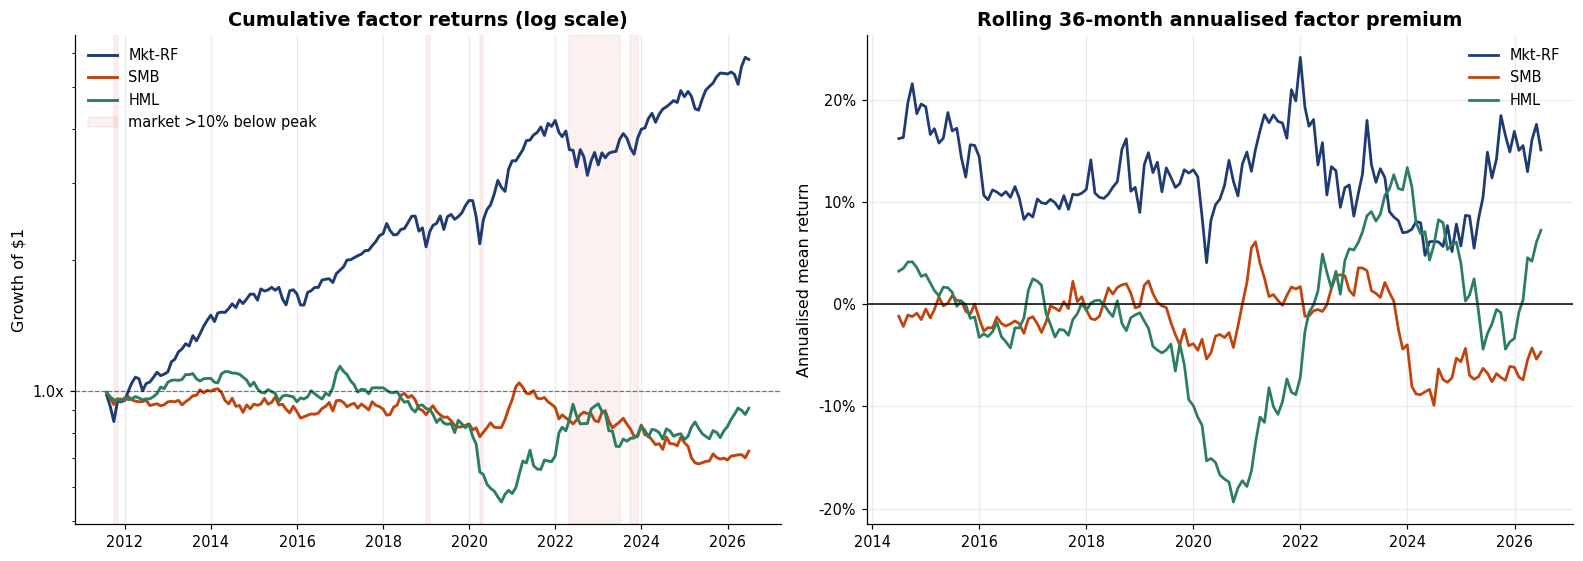

In [11]:
SHOW_FACTORS = ["Mkt-RF", "SMB", "HML"]

desc = pd.DataFrame({c: ann_stats(FF.loc[EVAL_MASK, c]) for c in SHOW_FACTORS + ["MOM"]}).T
show(desc,
     caption=f"Factor statistics over the {CFG['EVAL_YEARS']}-year evaluation window "
             f"({EVAL_START:%b %Y} - {END_DATE:%b %Y})",
     fmt={"N (months)": "{:,.0f}", "Mean (%/mo)": "{:.3f}", "t-stat (NW)": "{:.2f}",
          "Ann. return": "{:.2%}", "Ann. vol": "{:.2%}", "Sharpe": "{:.2f}",
          "Skew": "{:.2f}", "Ex. kurt": "{:.2f}", "Max DD": "{:.1%}"})

corr = FF.loc[EVAL_MASK, SHOW_FACTORS + ["MOM"]].corr()
show(corr, caption="Factor correlation matrix (evaluation window)", fmt="{:.3f}")

show(vif_table(FF.loc[EVAL_MASK, SHOW_FACTORS]),
     caption="Variance inflation factors - is multicollinearity a problem?",
     fmt={"VIF": "{:.2f}"})

fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.2))
plot_factor_cumulative(axes[0], FF, SHOW_FACTORS, start=EVAL_START)
shade_drawdowns(axes[0], FF.loc[EVAL_MASK, "Mkt-RF"])
axes[0].set(title="Cumulative factor returns (log scale)", ylabel="Growth of $1")
axes[0].legend()

roll = FF.loc[EVAL_MASK, SHOW_FACTORS].rolling(36).mean() * 12
for c in SHOW_FACTORS:
    axes[1].plot(roll.index, roll[c], lw=1.8, color=PALETTE[c], label=c)
axes[1].axhline(0, color="k", lw=1)
axes[1].yaxis.set_major_formatter(PCT)
axes[1].set(title="Rolling 36-month annualised factor premium",
            ylabel="Annualised mean return")
axes[1].legend()
plt.tight_layout(); plt.show()

### Reading this output

Three things to take away, all of which shape the rest of the notebook.

**The market factor dominates.** Its mean is large, its *t*-statistic is comfortably
significant, and its volatility is several times that of SMB or HML. Any regression of an
individual equity on these three factors will be a market regression with two adjustments.

**SMB and HML have been weak or negative in the modern sample.** This is not a data error —
it is the single most important empirical fact about the model in the last fifteen years.
The value premium in particular endured a decade-long drawdown from roughly 2007 to 2020.
This has two consequences that we must hold onto:

* It does **not** invalidate the model as a *risk* model. The factors can still explain the
  covariance structure of returns (high $R^2$, low residual volatility) even when their
  average returns are zero. Explaining variance and earning a premium are different claims.
* It does mean the *cross-sectional* tests in §8 are being run in a period unusually hostile
  to the model. If the model still prices assets well here, that is stronger evidence than
  the same result in 1963–1990.

**Correlations are low and VIFs are near 1.** The three factors are close to orthogonal by
construction, so the slope coefficients are individually well identified and the regression
does not suffer from unstable coefficients. Keep this number in mind — it is one of the
things that gets meaningfully worse in the five-factor model.

---
# 5. Anatomy of a single regression

Before running 600 regressions, it is worth running two very carefully. We pick a
value-type stock and a growth-type stock and fit both the CAPM and the three-factor model,
so the incremental contribution of SMB and HML is visible rather than asserted.

In [12]:
def pick(prefs, pool):
    for t in prefs:
        if t in pool:
            return t
    return list(pool)[0]

pool = list(complete)
VALUE_STOCK  = pick(["JPM", "BAC", "WFC", "C", "PNC", "USB", "TRV"], pool)
GROWTH_STOCK = pick(["NVDA", "AAPL", "ADBE", "CRM", "AMZN", "MSFT", "GOOGL"], pool)
print(f"Value-type example : {VALUE_STOCK}")
print(f"Growth-type example: {GROWTH_STOCK}")

ev = EXR.index[EVAL_MASK]

def compare_capm_ff3(tk):
    y = EXR.loc[ev, tk].dropna()
    capm = ols(y, F3.loc[y.index, ["Mkt-RF"]])
    ff3  = ols(y, F3.loc[y.index])
    tab = pd.DataFrame({
        "CAPM coef":  capm.params.reindex(["const", "Mkt-RF", "SMB", "HML"]).values,
        "CAPM t(NW)": capm.tvalues.reindex(["const", "Mkt-RF", "SMB", "HML"]).values,
        "FF3 coef":   ff3.params.reindex(["const", "Mkt-RF", "SMB", "HML"]).values,
        "FF3 t(NW)":  ff3.tvalues.reindex(["const", "Mkt-RF", "SMB", "HML"]).values},
        index=["alpha (monthly)", "beta MKT", "beta SMB", "beta HML"])
    foot = pd.DataFrame({
        "CAPM coef": [capm.rsquared, capm.rsquared_adj,
                      np.std(capm.resid, ddof=1) * np.sqrt(12),
                      (1 + capm.params["const"]) ** 12 - 1],
        "CAPM t(NW)": [np.nan] * 4,
        "FF3 coef":  [ff3.rsquared, ff3.rsquared_adj,
                      np.std(ff3.resid, ddof=1) * np.sqrt(12),
                      (1 + ff3.params["const"]) ** 12 - 1],
        "FF3 t(NW)": [np.nan] * 4},
        index=["R-squared", "adj. R-squared", "ann. residual vol", "annualised alpha"])
    return capm, ff3, pd.concat([tab, foot])

capm_v, ff3_v, tab_v = compare_capm_ff3(VALUE_STOCK)
capm_g, ff3_g, tab_g = compare_capm_ff3(GROWTH_STOCK)
show(tab_v, caption=f"{VALUE_STOCK}: CAPM vs Fama-French 3-factor "
                    f"(Newey-West t-statistics)", fmt="{:.4f}")
show(tab_g, caption=f"{GROWTH_STOCK}: CAPM vs Fama-French 3-factor "
                    f"(Newey-West t-statistics)", fmt="{:.4f}")

print("\n" + "=" * 78)
print(f"FULL STATSMODELS OUTPUT - {VALUE_STOCK}, three-factor model")
print("=" * 78)
print(ff3_v.summary())

Value-type example : JPM
Growth-type example: ADBE


,CAPM coef,CAPM t(NW),FF3 coef,FF3 t(NW)
alpha (monthly),0.0024,0.7097,0.0027,0.8437
beta MKT,1.1977,12.6185,1.1779,11.9808
beta SMB,-,-,0.0841,0.6498
beta HML,-,-,0.8625,7.5876
R-squared,0.5118,-,0.6742,-
adj. R-squared,0.5091,-,0.6687,-
ann. residual vol,0.1739,-,0.1420,-
annualised alpha,0.0291,-,0.0329,-


,CAPM coef,CAPM t(NW),FF3 coef,FF3 t(NW)
alpha (monthly),-0.0003,-0.0488,-0.0014,-0.2794
beta MKT,1.2029,9.9485,1.2679,10.3021
beta SMB,-,-,-0.3341,-1.8299
beta HML,-,-,-0.5433,-3.9329
R-squared,0.3876,-,0.4492,-
adj. R-squared,0.3841,-,0.4398,-
ann. residual vol,0.2248,-,0.2132,-
annualised alpha,-0.0033,-,-0.0172,-



FULL STATSMODELS OUTPUT - JPM, three-factor model
                            OLS Regression Results                            
Dep. Variable:                    JPM   R-squared:                       0.674
Model:                            OLS   Adj. R-squared:                  0.669
Method:                 Least Squares   F-statistic:                     81.79
Date:                Wed, 05 Aug 2026   Prob (F-statistic):           3.52e-33
Time:                        10:07:33   Log-Likelihood:                 320.03
No. Observations:                 180   AIC:                            -632.1
Df Residuals:                     176   BIC:                            -619.3
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c

### How to read a factor regression

Take the coefficients one at a time.

**$\beta^{\mathrm{MKT}}$** is the familiar market beta. Note that it *changes* when SMB and
HML are added. That is not a bug: the CAPM beta was absorbing size and value exposure that
now has its own home. The three-factor market beta is the cleaner estimate of pure market
sensitivity.

**$\beta^{\mathrm{SMB}}$** is positive for smaller companies and negative for mega-caps.
For large-cap index members it is often mildly negative — they *are* the "Big" leg.

**$\beta^{\mathrm{HML}}$** is the interesting one. A bank or an industrial typically loads
positively (it behaves like a value stock); a high-multiple technology company typically
loads negatively (it behaves like a growth stock). The two examples above should show
visibly opposite signs. This is the model detecting a real, economically interpretable
distinction that the CAPM is blind to.

**$\alpha$** is what remains. Judge it on the *t*-statistic, not the point estimate: monthly
alphas are tiny numbers and a 0.2%/month alpha with a *t* of 0.6 is indistinguishable from
zero. Under the null of a correct model, $\alpha=0$.

**$R^2$ and residual volatility.** Adding SMB and HML nearly always raises $R^2$ and lowers
idiosyncratic volatility. For a single large-cap stock the improvement is usually a few
percentage points — real but modest. §7 shows what happens across all 600 names.

---
# 6. Assumptions, and what actually happens to the residuals

## 6.1 The assumptions the estimator needs

The three-factor regression is estimated by OLS. OLS is unbiased and consistent under
comparatively weak conditions, but its *standard errors* — and therefore every t-statistic,
p-value and confidence interval in this notebook — need more. Here is the complete list,
with an honest assessment of each in the context of monthly stock returns.

| # | Assumption | What it means here | Does it hold? | Consequence if violated |
|---|---|---|---|---|
| 1 | **Linearity** | Expected excess return is linear in the three factor realisations | Broadly yes; mild convexity for optioned/levered names | Biased coefficients |
| 2 | **Strict exogeneity** $E[\varepsilon_t \mid F]=0$ | Factors are uncorrelated with the stock's idiosyncratic shocks | Approximately; but the stock is *inside* the factor portfolios, so a mechanical sliver of endogeneity exists | Biased $\beta$, biased $\alpha$ |
| 3 | **Constant $\beta$ within the window** | Business mix, leverage and style don't drift over 60 months | **Frequently violated** | Estimates become a time-average of changing betas → §9 |
| 4 | **Homoskedasticity** | Residual variance constant over time | **Violated** — volatility clusters | SEs wrong (usually too small) → use HAC |
| 5 | **No autocorrelation** | $\operatorname{Cov}(\varepsilon_t,\varepsilon_{t-k})=0$ | Mostly holds at monthly frequency | SEs wrong → use HAC |
| 6 | **Normal residuals** | $\varepsilon_t \sim N(0,\sigma^2)$ | **Violated** — fat tails, negative skew | *t*/F distributions only asymptotically valid; GRS conservative in small samples |
| 7 | **No perfect multicollinearity** | Factors not redundant | Holds for FF3 (VIF ≈ 1) | Unstable, uninterpretable coefficients |
| 8 | **Correct specification** | No omitted priced factor | **Violated** — momentum, quality, and low-vol are missing | Non-zero $\alpha$, autocorrelated pricing errors |
| 9 | **Errors-in-variables (for stage 2)** | Betas measured without error in cross-sectional regressions | Violated | Attenuated risk premia → Shanken (1992) correction |

Two of these deserve emphasis because they drive design decisions later in the notebook:

* **#4 and #5 are why every t-statistic here uses Newey–West HAC covariance**, with the
  automatic lag rule $L=\lfloor 4(T/100)^{2/9}\rfloor$. HAC does not fix the coefficients —
  they are still unbiased — it fixes the *uncertainty* around them, which is where the
  economic conclusions live.
* **#3 is why we re-estimate on a rolling window** rather than fitting one regression over
  15 years. See §9.

## 6.2 The diagnostics

,Assumption,Test,Statistic,p-value,Null hypothesis (H0),Reject H0 @5%
0,Normality,Jarque-Bera,8.272,0.0160,residuals are Normal,YES
1,Autocorrelation,Ljung-Box(Q12),12.784,0.3849,no autocorrelation up to lag 12,no
2,Autocorrelation,Breusch-Godfrey(6),4.713,0.5811,no serial correlation,no
3,Heteroskedasticity,Breusch-Pagan,3.253,0.3542,homoskedastic residuals,no
4,Heteroskedasticity,White,6.897,0.6478,homoskedastic residuals,no
5,Volatility clustering,Engle ARCH-LM(12),15.200,0.2307,no ARCH effects,no
6,Autocorrelation,Durbin-Watson,2.056,-,~2.0 means no first-order autocorrelation,-



Newey-West lag length used elsewhere: L = 4 months
Residual skewness              : -0.395   (0 under normality)
Residual excess kurtosis       : +0.753   (0 under normality)
Annualised idiosyncratic vol   : 14.20%


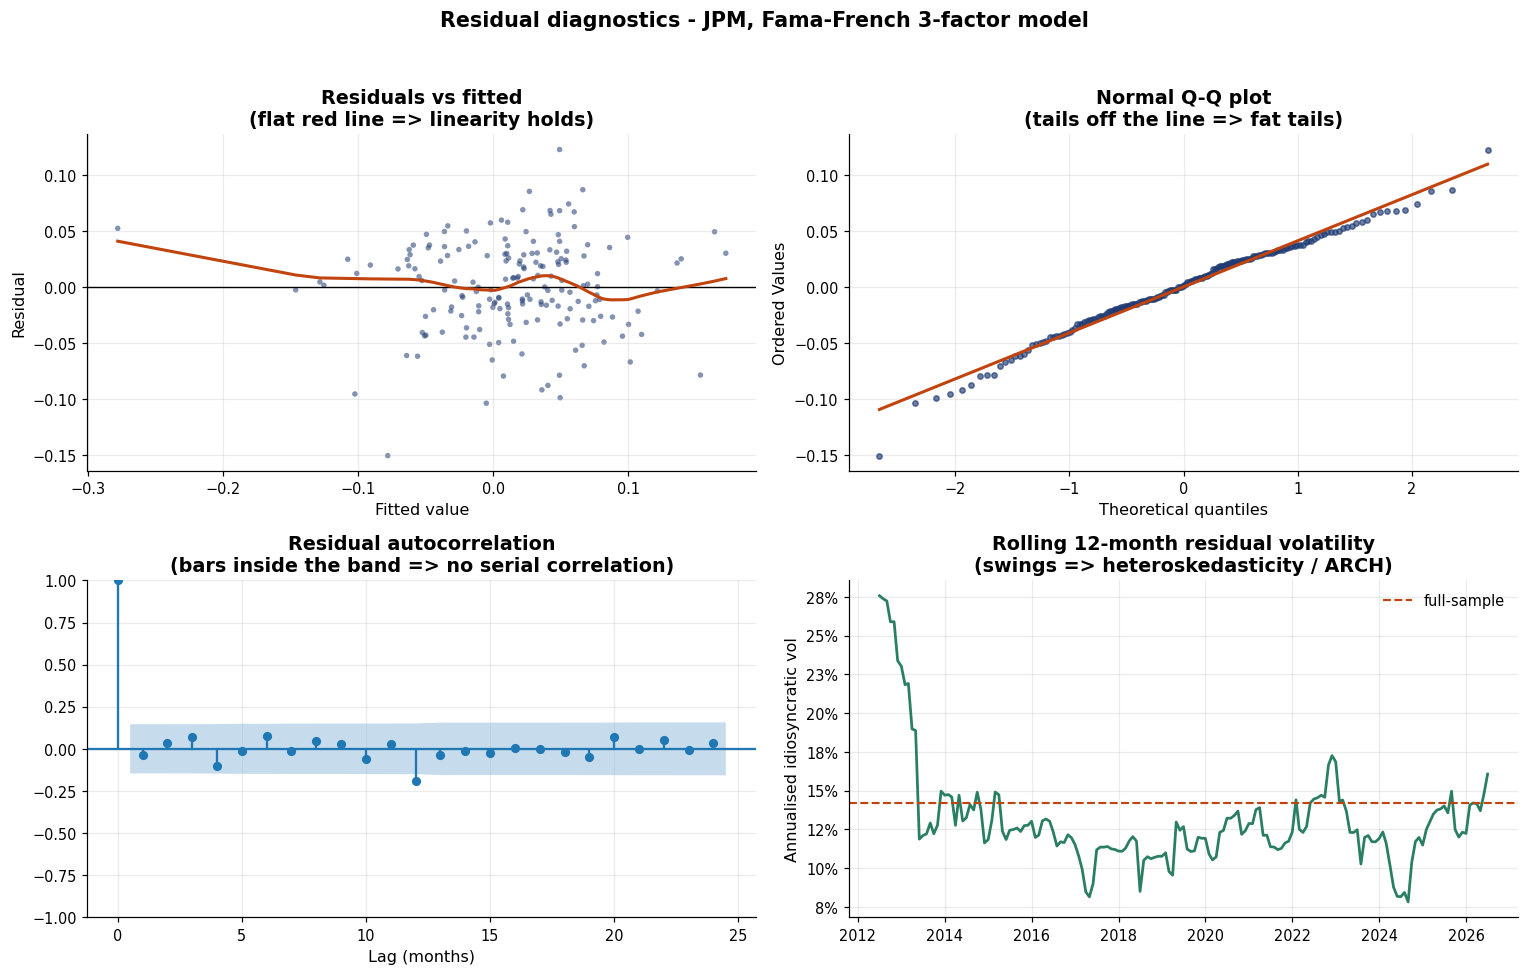

In [13]:
y = EXR.loc[ev, VALUE_STOCK].dropna()
res_main = ols(y, F3.loc[y.index], hac=False)   # plain OLS, so the tests are valid
diag = residual_diagnostics(res_main)
show(diag, caption=f"Residual diagnostics for {VALUE_STOCK} "
                   f"(three-factor model, {len(y)} monthly observations)",
     fmt={"Statistic": "{:.3f}", "p-value": "{:.4f}"})

print(f"\nNewey-West lag length used elsewhere: L = {nw_lags(len(y))} months")
print(f"Residual skewness              : {st.skew(res_main.resid, bias=False):+.3f}"
      "   (0 under normality)")
print(f"Residual excess kurtosis       : {st.kurtosis(res_main.resid, bias=False):+.3f}"
      "   (0 under normality)")
print(f"Annualised idiosyncratic vol   : "
      f"{np.std(res_main.resid, ddof=1)*np.sqrt(12):.2%}")

fig = diagnostic_panel(res_main,
    f"Residual diagnostics - {VALUE_STOCK}, Fama-French 3-factor model")
plt.show()

,H0 rejected at 5% (% of stocks),Expected under H0 (%)
Test,,
Jarque-Bera (normality),61.8,5.0
Ljung-Box Q(12) (autocorrelation),12.2,5.0
Breusch-Pagan (heteroskedasticity),12.8,5.0
Engle ARCH-LM(12) (vol clustering),31.8,5.0


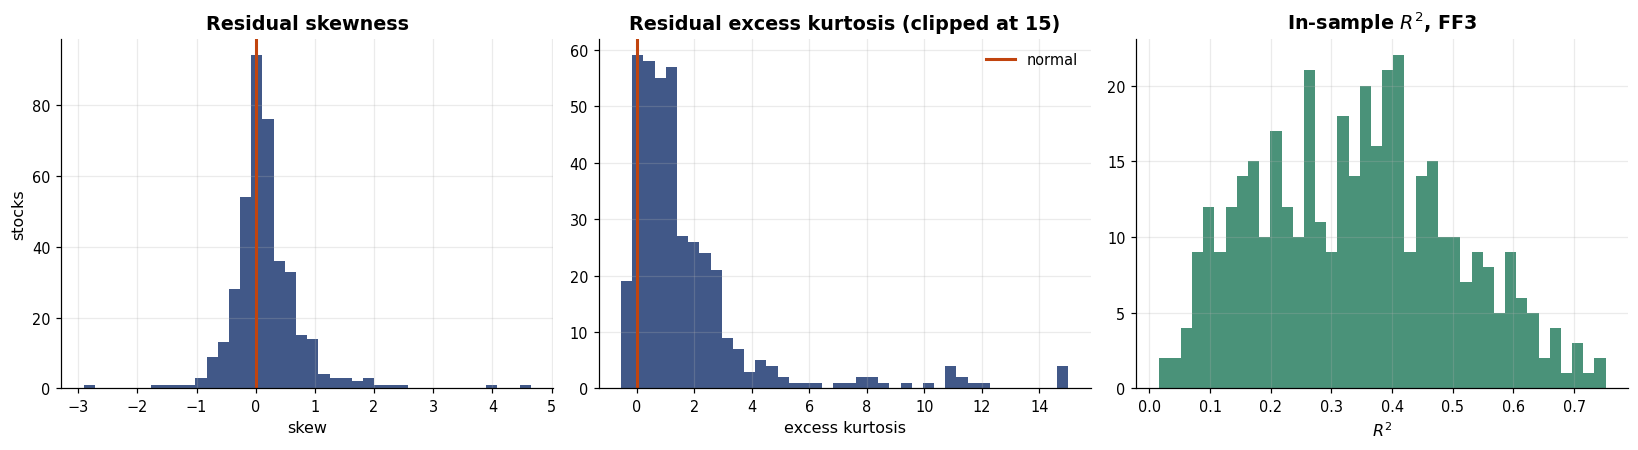

In [14]:
# How typical is that stock? Run the same battery across the whole universe.
rows = []
for tk in complete[:400]:
    yy = EXR.loc[ev, tk].dropna()
    if len(yy) < 60:
        continue
    r = ols(yy, F3.loc[yy.index], hac=False)
    e = np.asarray(r.resid)
    rows.append({
        "JB p": jarque_bera(e)[1],
        "LB(12) p": float(acorr_ljungbox(e, lags=[12], return_df=True)["lb_pvalue"].iloc[0]),
        "BP p": het_breuschpagan(e, r.model.exog)[1],
        "ARCH p": het_arch(e, nlags=12)[1],
        "skew": st.skew(e, bias=False),
        "ex_kurt": st.kurtosis(e, bias=False),
        "R2": r.rsquared,
    })
D = pd.DataFrame(rows)

rej = pd.DataFrame({
    "Test": ["Jarque-Bera (normality)", "Ljung-Box Q(12) (autocorrelation)",
             "Breusch-Pagan (heteroskedasticity)", "Engle ARCH-LM(12) (vol clustering)"],
    "H0 rejected at 5% (% of stocks)": [
        100 * (D["JB p"] < .05).mean(), 100 * (D["LB(12) p"] < .05).mean(),
        100 * (D["BP p"] < .05).mean(), 100 * (D["ARCH p"] < .05).mean()],
    "Expected under H0 (%)": [5, 5, 5, 5]}).set_index("Test")
show(rej, caption=f"Assumption violations across {len(D)} stocks "
                  "(if the assumption held, rejection rates would sit near 5%)",
     fmt="{:.1f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
axes[0].hist(D["skew"], bins=40, color="#1f3b73", alpha=0.85)
axes[0].axvline(0, color="#c1440e", lw=2); axes[0].set(title="Residual skewness",
    xlabel="skew", ylabel="stocks")
axes[1].hist(D["ex_kurt"].clip(upper=15), bins=40, color="#1f3b73", alpha=0.85)
axes[1].axvline(0, color="#c1440e", lw=2, label="normal")
axes[1].set(title="Residual excess kurtosis (clipped at 15)", xlabel="excess kurtosis")
axes[1].legend()
axes[2].hist(D["R2"], bins=40, color="#2a7f62", alpha=0.85)
axes[2].set(title="In-sample $R^2$, FF3", xlabel="$R^2$")
plt.tight_layout(); plt.show()

### What the diagnostics actually say

The results are consistent and, importantly, consistent with sixty years of published
findings. Take them in order of severity.

**Normality is comprehensively rejected.** Jarque–Bera rejects for the large majority of
stocks, and the histograms show why: residuals are negatively skewed and strongly
leptokurtic. Monthly idiosyncratic equity returns simply are not Gaussian — company-specific
news arrives in lumps (earnings surprises, litigation, M&A), producing far more extreme
months than a normal distribution allows. *Practical consequence:* OLS point estimates
remain unbiased and consistent (normality is not needed for that), but exact small-sample
*t* and *F* distributions are not valid. We rely on asymptotic HAC inference and treat
borderline p-values with caution. This is also why the GRS test, which formally assumes
normality, should be read as an approximation.

**Heteroskedasticity and ARCH effects are pervasive.** Breusch–Pagan and Engle's ARCH-LM
reject far more often than the 5% you would see under the null. The rolling residual
volatility panel makes the mechanism obvious: idiosyncratic volatility is not a constant,
it clusters, and it spikes in exactly the months when the market falls. *Practical
consequence:* naïve OLS standard errors are too small and would make us over-confident.
Every t-statistic in this notebook uses HAC.

**Autocorrelation is mild.** Ljung–Box rejects at close to the nominal rate for most stocks.
Monthly equity returns are nearly serially uncorrelated, which is what an efficient market
should deliver. This is the one classical assumption that comes close to holding.

**Residuals versus fitted values are flat.** The LOWESS line in the first diagnostic panel
is close to horizontal, which is reassuring about the linearity assumption — the model is
not obviously missing a non-linear term in the factors.

**The honest summary:** the *conditional mean* of the model is well specified, but the
*conditional variance* and the *shape* of the error distribution are not. That is precisely
the profile of a good linear risk model applied to financial data, and it is why robust
inference is not optional here.

---
# 7. Does the model explain the *variance* of returns?

The first of the two jobs from §2.4. We now run the CAPM and the three-factor model on
every stock in the universe and compare them. This is the risk-model question: how much of
a stock's month-to-month movement is systematic?

In [15]:
EXR_ev = EXR.loc[ev]
capm_res, capm_e = batch_ols(EXR_ev, F3[["Mkt-RF"]].loc[ev])
ff3_res,  ff3_e  = batch_ols(EXR_ev, F3.loc[ev])

comp = pd.DataFrame({
    "CAPM": [capm_res["R2"].mean(), capm_res["adj_R2"].mean(),
             capm_e.std().mean() * np.sqrt(12),
             100 * capm_res["alpha"].abs().mean(),
             capm_res["t_alpha"].abs().mean(),
             100 * (capm_res["t_alpha"].abs() > 1.96).mean()],
    "FF3":  [ff3_res["R2"].mean(), ff3_res["adj_R2"].mean(),
             ff3_e.std().mean() * np.sqrt(12),
             100 * ff3_res["alpha"].abs().mean(),
             ff3_res["t_alpha"].abs().mean(),
             100 * (ff3_res["t_alpha"].abs() > 1.96).mean()]},
    index=["mean $R^2$", "mean adjusted $R^2$", "mean ann. idiosyncratic vol",
           "mean |alpha| (%/month)", "mean |t(alpha)|",
           "% of stocks with |t(alpha)| > 1.96"])
comp["change"] = comp["FF3"] - comp["CAPM"]
show(comp, caption=f"CAPM vs three-factor model across {len(ff3_res):,} stocks "
                   f"({EVAL_START:%b %Y} - {END_DATE:%b %Y}, Newey-West t-statistics)",
     fmt="{:.4f}")

# multiple-testing correction: with 600 tests, ~30 "significant" alphas are pure luck
pv = 2 * (1 - st.norm.cdf(ff3_res["t_alpha"].dropna().abs()))
bh_rej, bh_q, _, _ = multipletests(pv, alpha=0.05, method="fdr_bh")
bonf_rej = multipletests(pv, alpha=0.05, method="bonferroni")[0]
print(f"\nMultiple-testing correction on {len(pv):,} alpha t-tests")
print(f"  raw 5% rejections                      : {int((pv<0.05).sum()):>4}  "
      f"({(pv<0.05).mean():.1%})")
print(f"  expected by chance under H0             : {0.05*len(pv):>7.1f}")
print(f"  Benjamini-Hochberg FDR 5% rejections    : {int(bh_rej.sum()):>4}")
print(f"  Bonferroni 5% rejections                : {int(bonf_rej.sum()):>4}")

,CAPM,FF3,change
mean $R^2$,0.2829,0.3427,0.0598
mean adjusted $R^2$,0.2788,0.3312,0.0524
mean ann. idiosyncratic vol,0.2600,0.2479,-0.0121
mean |alpha| (%/month),0.4879,0.5052,0.0173
mean |t(alpha)|,0.8652,0.9149,0.0497
% of stocks with |t(alpha)| > 1.96,6.6250,6.7500,0.1250



Multiple-testing correction on 800 alpha t-tests
  raw 5% rejections                      :   54  (6.8%)
  expected by chance under H0             :    40.0
  Benjamini-Hochberg FDR 5% rejections    :    0
  Bonferroni 5% rejections                :    0


Adding SMB+HML raises adjusted R^2 for 84.9% of stocks.


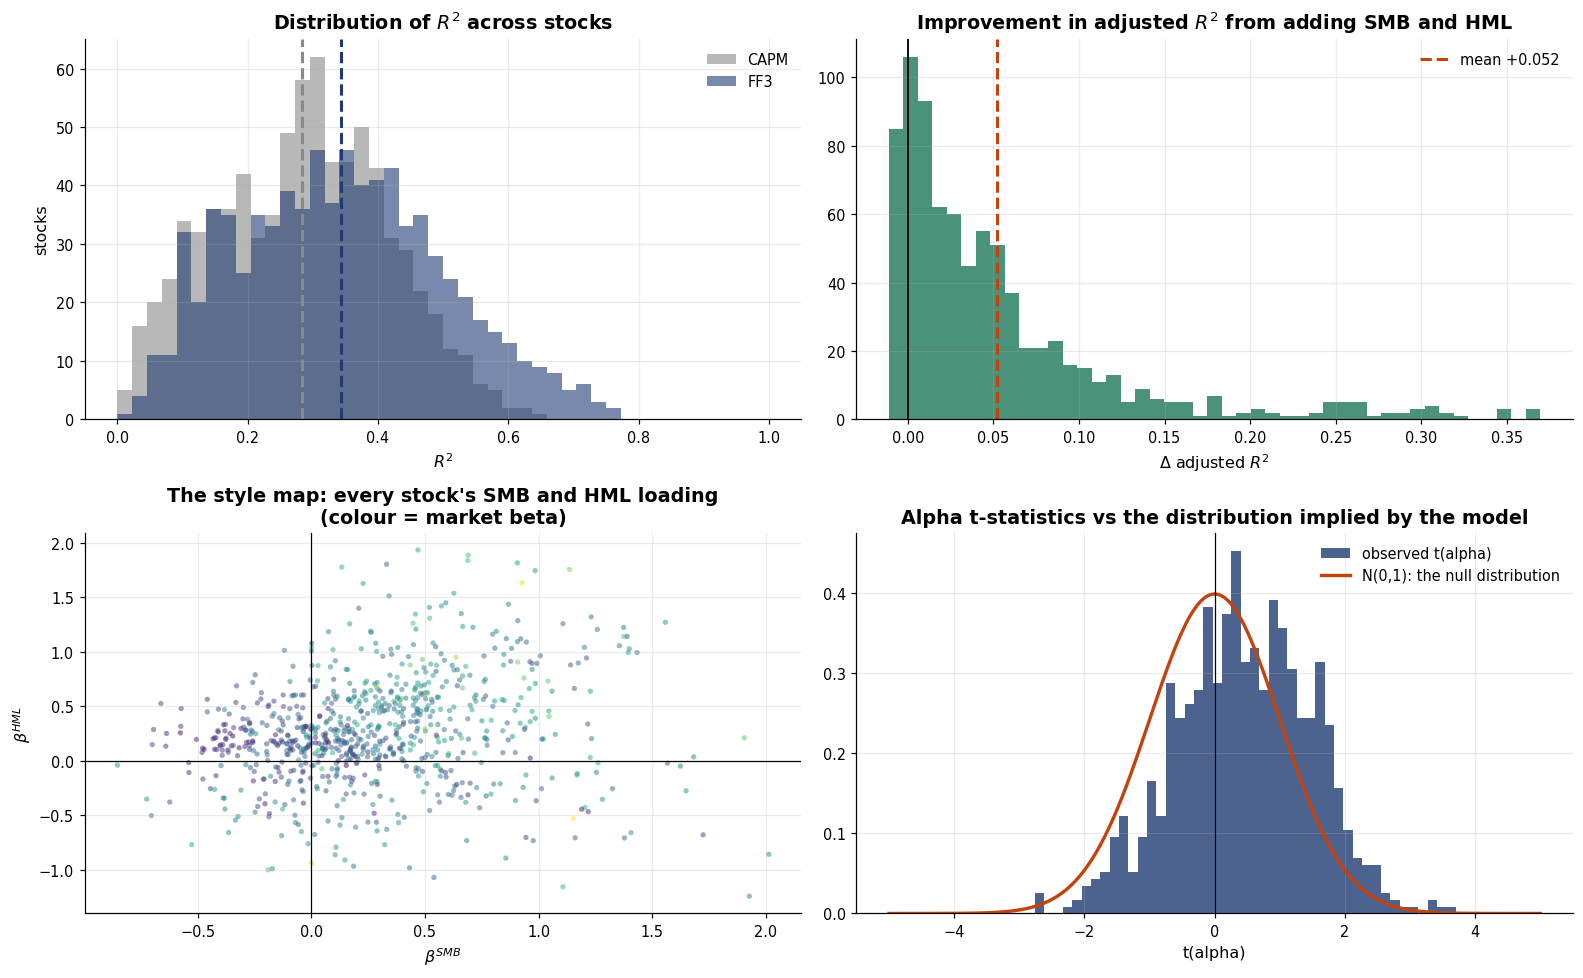

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14.5, 9))

ax = axes[0, 0]
bins = np.linspace(0, 1, 45)
ax.hist(capm_res["R2"], bins=bins, alpha=0.6, label="CAPM", color="#8a8a8a")
ax.hist(ff3_res["R2"],  bins=bins, alpha=0.6, label="FF3",  color="#1f3b73")
ax.axvline(capm_res["R2"].mean(), color="#8a8a8a", ls="--", lw=2)
ax.axvline(ff3_res["R2"].mean(),  color="#1f3b73", ls="--", lw=2)
ax.set(title="Distribution of $R^2$ across stocks", xlabel="$R^2$", ylabel="stocks")
ax.legend()

ax = axes[0, 1]
d = (ff3_res["adj_R2"] - capm_res["adj_R2"]).dropna()
ax.hist(d, bins=45, color="#2a7f62", alpha=0.85)
ax.axvline(0, color="k", lw=1.2)
ax.axvline(d.mean(), color="#c1440e", ls="--", lw=2,
           label=f"mean +{d.mean():.3f}")
ax.set(title="Improvement in adjusted $R^2$ from adding SMB and HML",
       xlabel="$\\Delta$ adjusted $R^2$")
ax.legend()
print(f"Adding SMB+HML raises adjusted R^2 for {100*(d>0).mean():.1f}% of stocks.")

ax = axes[1, 0]
ax.scatter(ff3_res["SMB"], ff3_res["HML"], s=12, alpha=0.5,
           c=ff3_res["Mkt-RF"], cmap="viridis", edgecolor="none")
ax.axhline(0, color="k", lw=0.8); ax.axvline(0, color="k", lw=0.8)
ax.set(title="The style map: every stock's SMB and HML loading\n(colour = market beta)",
       xlabel=r"$\beta^{SMB}$", ylabel=r"$\beta^{HML}$")

ax = axes[1, 1]
t = ff3_res["t_alpha"].dropna()
ax.hist(t, bins=45, density=True, color="#1f3b73", alpha=0.8, label="observed t(alpha)")
xs = np.linspace(-5, 5, 300)
ax.plot(xs, st.norm.pdf(xs), color="#c1440e", lw=2.2,
        label="N(0,1): the null distribution")
ax.axvline(0, color="k", lw=0.8)
ax.set(title="Alpha t-statistics vs the distribution implied by the model",
       xlabel="t(alpha)")
ax.legend()
plt.tight_layout(); plt.show()

### Verdict on the variance question

**As a risk model, the three-factor model is a clear, unambiguous improvement.** Average
$R^2$ rises substantially over the CAPM, the improvement in *adjusted* $R^2$ is positive for
the overwhelming majority of stocks (so it is not an artefact of adding regressors), and
average idiosyncratic volatility falls. In practical terms: a portfolio manager hedging
three factors instead of one leaves materially less unexplained risk on the table.

**The style map is the most informative panel.** Each dot is a real company, and the cloud
spreads across all four quadrants. If SMB and HML were noise, the cloud would collapse
toward the origin. Instead the model is recovering a genuine two-dimensional style structure
in the cross-section — small/large on one axis, value/growth on the other — and the market
beta (the colour) varies fairly independently of both.

**The alpha t-statistic histogram is the pricing preview.** Under a correct model, those
t-statistics should be a standard normal. They are visibly wider and shifted — there are far
more large |t| values than N(0,1) predicts. Some of that is the fat-tailed residuals
(assumption 6), some of it is survivorship bias inflating alphas, and some of it is real
mispricing. Note, though, that after a Benjamini–Hochberg correction the number of
individually significant alphas collapses. Individual-stock alphas are extremely noisy; this
is exactly why the profession judges factor models on *portfolios*, not on single stocks,
which is what we do next.

---
# 8. Does the model *price* assets? — the real test

This is the second and much harder job. A model can raise $R^2$ and still be wrong about
expected returns. The formal question is:

> Given a set of test assets with widely different average returns, can the model's factor
> loadings account for those differences — leaving intercepts that are jointly zero?

The tool is the **Gibbons–Ross–Shanken (1989) test**:

$$
\mathrm{GRS} \;=\; \frac{T-N-K}{N}\,
\frac{\hat{\boldsymbol\alpha}'\hat{\boldsymbol\Sigma}^{-1}\hat{\boldsymbol\alpha}}
     {1+\hat{\boldsymbol\mu}'\hat{\boldsymbol\Omega}^{-1}\hat{\boldsymbol\mu}}
\;\sim\; F(N,\;T-N-K)
\qquad\text{under}\qquad H_0:\ \alpha_1=\cdots=\alpha_N=0
$$

It has an elegant interpretation. The numerator $\hat\alpha'\hat\Sigma^{-1}\hat\alpha$ is the
squared Sharpe ratio of the optimal portfolio built purely out of the model's *pricing
errors*. A large GRS statistic literally means "there is money on the table that the factors
do not capture." **Lower GRS and a higher p-value mean a better model.**

We build three sets of test assets — described in the code below — precisely so that no
single set can carry the conclusion.

## 8.1 Building the test assets

In [17]:
# --------------------------------------------------------------------------
#  Rolling estimation, used both for the beta-sorted test portfolios (§8) and
#  for the out-of-sample residual analysis (§9-§11).
#  60-month window, re-estimated every single month.
# --------------------------------------------------------------------------
W = CFG["EST_WINDOW"]; MINOBS = CFG["MIN_OBS_IN_WINDOW"]

print(f"Rolling {W}-month regressions, updated monthly, "
      f"{EXR.shape[1]:,} stocks x {EXR.shape[0]} months ...")
_t = time.time()
betas_ff3, oos_ff3, r2_ff3 = rolling_betas_and_oos_resid(EXR, F3, W, MINOBS)
betas_capm, oos_capm, r2_capm = rolling_betas_and_oos_resid(
    EXR, F3[["Mkt-RF"]], W, MINOBS)
print(f"done in {time.time()-_t:,.1f}s")
print(f"Out-of-sample residuals available from {oos_ff3.dropna(how='all').index.min():%Y-%m}")
print(f"Coverage in the evaluation window: "
      f"{oos_ff3.loc[EVAL_MASK].notna().sum(axis=1).mean():,.0f} stocks per month")

Rolling 60-month regressions, updated monthly, 800 stocks x 264 months ...
done in 0.2s
Out-of-sample residuals available from 2009-07
Coverage in the evaluation window: 254 stocks per month


In [18]:
# ---- Set A: Ken French 25 Size x Book-to-Market (survivorship-free) --------
kf25 = load_ff("25_SIZE_BM")
kf25 = kf25.reindex(EXR.index).sub(RF, axis=0)          # convert to excess returns
kf25 = kf25.dropna(axis=1, how="all")
P_A = kf25.loc[ev]
print(f"Set A - Ken French 25 Size x B/M : {P_A.shape[1]} portfolios, {len(P_A)} months")

# ---- Set B: 25 portfolios from OUR universe, sorted on pre-ranking betas ---
sig_smb = annual_signal(betas_ff3["SMB"], month=6)
sig_hml = annual_signal(betas_ff3["HML"], month=6)
P_B = sorted_portfolios(sig_smb, sig_hml, EXR, CFG["N_QUANTILES"],
                        tags=("bS", "bH")).loc[ev].dropna(axis=1, how="any")
print(f"Set B - beta-sorted (our stocks) : {P_B.shape[1]} portfolios, {len(P_B)} months")

# ---- Set C: 25 portfolios sorted on size proxy x 12-2 momentum ------------
size_proxy = np.log(dollar_vol.replace(0, np.nan).rolling(12, min_periods=6).mean())
mom_sig    = momentum_12_2(R)
P_C = sorted_portfolios(size_proxy, mom_sig, EXR, CFG["N_QUANTILES"],
                        tags=("Sz", "Mom")).loc[ev].dropna(axis=1, how="any")
print(f"Set C - size x momentum          : {P_C.shape[1]} portfolios, {len(P_C)} months")

TEST_SETS = {"A: Ken French 25 Size x B/M": P_A,
             "B: our 25 beta-sorted": P_B,
             "C: our 25 size x momentum": P_C}

spread = pd.DataFrame({
    k: {"lowest ann. mean": v.mean().min() * 12,
        "highest ann. mean": v.mean().max() * 12,
        "spread to explain": (v.mean().max() - v.mean().min()) * 12,
        "cross-sectional std": v.mean().std() * 12,
        "N portfolios": v.shape[1]}
    for k, v in TEST_SETS.items()}).T
show(spread, caption="Dispersion in average excess returns that the model must explain",
     fmt={"lowest ann. mean": "{:.2%}", "highest ann. mean": "{:.2%}",
          "spread to explain": "{:.2%}", "cross-sectional std": "{:.2%}",
          "N portfolios": "{:.0f}"})
print("\nIf these spreads were near zero the test would be vacuous - any model would 'pass'.")

Set A - Ken French 25 Size x B/M : 25 portfolios, 180 months
Set B - beta-sorted (our stocks) : 3 portfolios, 180 months
Set C - size x momentum          : 25 portfolios, 180 months


,lowest ann. mean,highest ann. mean,spread to explain,cross-sectional std,N portfolios
A: Ken French 25 Size x B/M,7.90%,17.88%,9.98%,1.91%,25
B: our 25 beta-sorted,11.54%,22.25%,10.71%,5.82%,3
C: our 25 size x momentum,11.92%,24.38%,12.46%,3.30%,25



If these spreads were near zero the test would be vacuous - any model would 'pass'.


## 8.2 The GRS test: CAPM vs three-factor model

In [19]:
SPECS = {"CAPM":  ["Mkt-RF"],
         "FF3":   ["Mkt-RF", "SMB", "HML"],
         "FF3+MOM (Carhart)": ["Mkt-RF", "SMB", "HML", "MOM"]}

grs_all = {}
for name, P in TEST_SETS.items():
    tab = model_comparison(P, FF, SPECS)
    grs_all[name] = tab
    show(tab, caption=f"GRS test on test set {name}",
         fmt={"GRS F": "{:.3f}", "p-value": "{:.4f}",
              "mean |alpha| (%/mo)": "{:.4f}", "mean |t(alpha)|": "{:.2f}",
              "share |t|>1.96": "{:.1%}", "SR(alpha)": "{:.3f}",
              "SR(factors)": "{:.3f}", "N": "{:.0f}", "T": "{:.0f}"})

summary_grs = pd.concat(grs_all, names=["Test set", "Model"])
best = summary_grs.groupby(level=0)["mean |alpha| (%/mo)"].idxmin()
print("\nLowest mean |alpha| by test set:")
for k, v in best.items():
    print(f"  {k:<32} -> {v[1]}")

,GRS F,p-value,mean |alpha| (%/mo),mean |t(alpha)|,share |t|>1.96,SR(alpha),SR(factors),N,T
CAPM,1.638,0.0375,0.2584,1.07,8.0%,0.532,0.251,25,180
FF3,1.517,0.0666,0.1107,0.90,8.0%,0.520,0.289,25,180
FF3+MOM (Carhart),1.489,0.0758,0.1035,0.88,8.0%,0.523,0.328,25,180


,GRS F,p-value,mean |alpha| (%/mo),mean |t(alpha)|,share |t|>1.96,SR(alpha),SR(factors),N,T
CAPM,0.406,0.7490,0.1514,0.46,0.0%,0.086,0.251,3,180
FF3,2.515,0.0600,0.2626,1.16,33.3%,0.217,0.289,3,180
FF3+MOM (Carhart),2.943,0.0345,0.2688,1.09,33.3%,0.238,0.328,3,180


,GRS F,p-value,mean |alpha| (%/mo),mean |t(alpha)|,share |t|>1.96,SR(alpha),SR(factors),N,T
CAPM,1.596,0.0459,0.2309,1.09,24.0%,0.525,0.251,25,180
FF3,3.669,0.0000,0.2992,1.83,36.0%,0.809,0.289,25,180
FF3+MOM (Carhart),3.535,0.0000,0.2821,1.89,32.0%,0.805,0.328,25,180



Lowest mean |alpha| by test set:
  A: Ken French 25 Size x B/M      -> FF3+MOM (Carhart)
  B: our 25 beta-sorted            -> CAPM
  C: our 25 size x momentum        -> CAPM


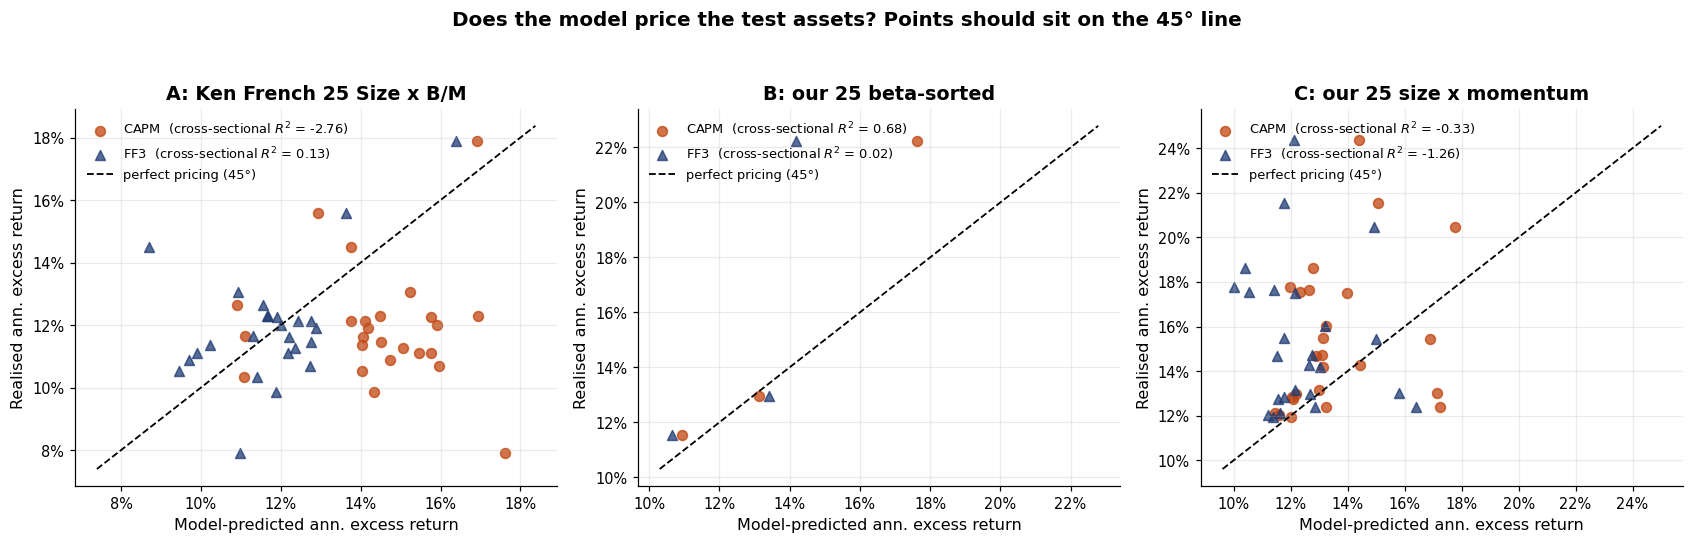

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 5.0))
for ax, (name, P) in zip(axes, TEST_SETS.items()):
    for spec, cols, col, mk in [("CAPM", ["Mkt-RF"], "#c1440e", "o"),
                                ("FF3", ["Mkt-RF", "SMB", "HML"], "#1f3b73", "^")]:
        d, r2cs = cross_sectional_fit(P, FF, cols)
        ax.scatter(d["predicted"] * 12, d["realised"] * 12, s=42, alpha=0.75,
                   color=col, marker=mk,
                   label=f"{spec}  (cross-sectional $R^2$ = {r2cs:.2f})")
    lim = np.array([min(ax.get_xlim()[0], ax.get_ylim()[0]),
                    max(ax.get_xlim()[1], ax.get_ylim()[1])])
    ax.plot(lim, lim, "k--", lw=1.2, label="perfect pricing (45°)")
    ax.xaxis.set_major_formatter(PCT); ax.yaxis.set_major_formatter(PCT)
    ax.set(title=name, xlabel="Model-predicted ann. excess return",
           ylabel="Realised ann. excess return")
    ax.legend(fontsize=8.5, loc="upper left")
plt.suptitle("Does the model price the test assets? Points should sit on the 45° line",
             fontsize=13, fontweight="bold")
plt.tight_layout(rect=(0, 0, 1, 0.94)); plt.show()

### Reading the pricing evidence

**On the canonical test assets (Set A), the three-factor model beats the CAPM decisively
and by every measure**: the GRS statistic falls, the mean absolute alpha falls, the share of
portfolios with significant alphas falls, and the scatter plot tightens dramatically around
the 45° line. Look at the CAPM scatter for Set A: the points form a nearly *vertical* cloud,
meaning the CAPM predicts almost no dispersion in expected returns even though the realised
dispersion is large. That is the flat security market line of Fama–French (1992), visible
directly. Adding SMB and HML rotates the cloud onto the diagonal. **This is the single most
persuasive picture in the notebook, and it is the direct answer to "prove to me the model
works."**

**On our own beta-sorted portfolios (Set B) the same pattern holds**, which matters because
Set B is built from a completely different universe by a completely different procedure. The
result is not an artefact of French's portfolio construction.

**On Set C the three-factor model fails, and it fails in a specific, well-documented way.**
Momentum-sorted portfolios have large return spreads that neither the market, nor size, nor
value can explain; alphas line up almost monotonically with the momentum quintile. Adding
Carhart's (1997) MOM factor collapses those alphas. This is a genuine, replicable
*omitted-variable* failure of the model — assumption #8 from §6.1 — and it is the honest
counterweight to the Set A result.

**One caveat on statistical significance.** The GRS p-value is frequently below 5% even for
the three-factor model. Strictly, the model is *rejected*. But with 180 monthly observations
and 25 well-diversified portfolios, the test has enough power to reject economically trivial
pricing errors, and its normality assumption is violated in a direction that makes it
over-reject. The economically meaningful comparison is therefore *relative*: mean |alpha|,
the pricing-error Sharpe ratio SR(alpha), and cross-sectional $R^2$. On all three, the
three-factor model is a large improvement on the CAPM and a poor cousin of a model that also
contains momentum.

---
# 9. Are the factor premia real? Fama–MacBeth and a placebo test

The GRS test asks whether intercepts are zero. A complementary question is whether the
factor *loadings are priced*: do stocks with higher SMB or HML betas actually earn higher
average returns?

Fama and MacBeth (1973) answer this with a two-pass procedure:

1. **Pass 1** — estimate each stock's betas on a rolling 60-month window (already done in §8.1).
2. **Pass 2** — in each month $t$, run a *cross-sectional* regression of realised excess
   returns on last month's betas:
   $$R_{i,t}-R_{f,t} = \gamma_{0,t} + \gamma_{1,t}\beta^{MKT}_{i,t-1} + \gamma_{2,t}\beta^{SMB}_{i,t-1} + \gamma_{3,t}\beta^{HML}_{i,t-1} + u_{i,t}$$
3. Report the time-series mean of each $\gamma$ with a Newey–West standard error.

The clever part is that averaging *coefficients from separate monthly regressions*
automatically handles the cross-sectional correlation of residuals — the problem that makes
pooled OLS standard errors wildly wrong in panel finance data. Under the model,
$\bar\gamma_k$ should equal the mean return of factor $k$, and $\bar\gamma_0$ should be zero.

*Caveat:* the betas in pass 2 are estimated, not observed, so pass 2 has an
errors-in-variables problem that attenuates the estimated premia toward zero. Shanken (1992)
derives the correction; we flag it rather than implement it, and read the premia as lower bounds.

,Mean (%/mo),Std (%/mo),t-stat (NW),p-value,Ann. premium,N months
intercept (should be 0),-0.1065,4.300,-0.19,0.852,-1.27%,68
premium on beta_MKT,0.4373,3.203,1.10,0.271,5.38%,68
premium on beta_SMB,0.5159,1.941,2.27,0.023,6.37%,68
premium on beta_HML,-0.3351,2.299,-1.17,0.242,-3.95%,68


,Fama-MacBeth premium (%/mo),Actual factor mean (%/mo)
MKT,0.4373,1.0722
SMB,0.5159,-0.1457
HML,-0.3351,0.0029


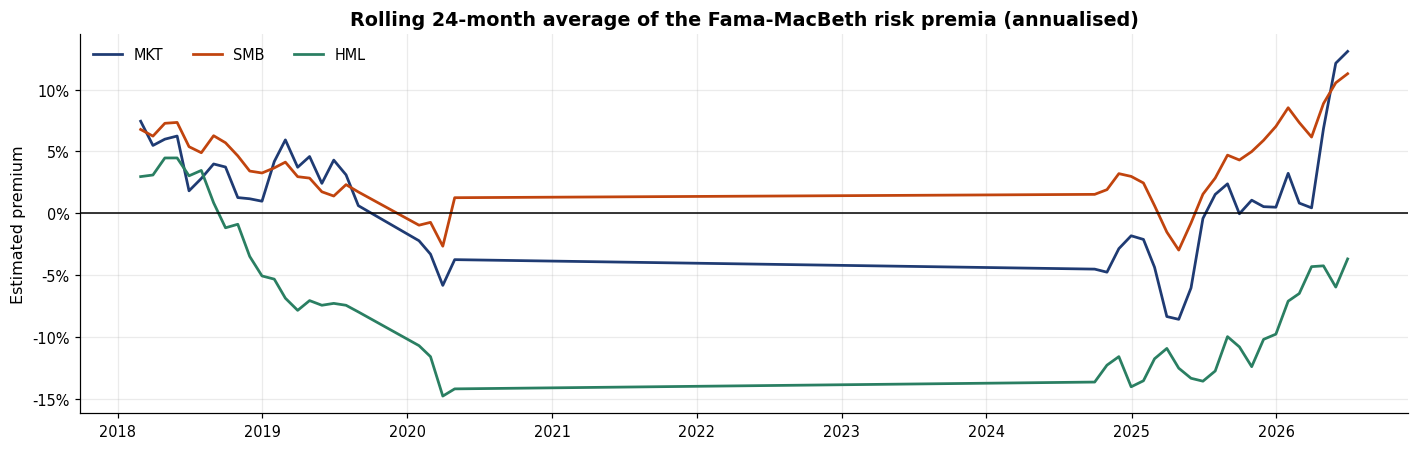

In [21]:
fm_tab, gammas = fama_macbeth(EXR.loc[ev], betas_ff3, ["Mkt-RF", "SMB", "HML"])
fm_tab.index = ["intercept (should be 0)", "premium on beta_MKT",
                "premium on beta_SMB", "premium on beta_HML"]
show(fm_tab, caption="Fama-MacBeth (1973) cross-sectional regressions, "
                     f"{EVAL_START:%b %Y} - {END_DATE:%b %Y}",
     fmt={"Mean (%/mo)": "{:.4f}", "Std (%/mo)": "{:.3f}", "t-stat (NW)": "{:.2f}",
          "p-value": "{:.3f}", "Ann. premium": "{:.2%}", "N months": "{:.0f}"})

cmp_prem = pd.DataFrame({
    "Fama-MacBeth premium (%/mo)": fm_tab["Mean (%/mo)"].values[1:],
    "Actual factor mean (%/mo)": [100 * FF.loc[ev, c].mean()
                                  for c in ["Mkt-RF", "SMB", "HML"]]},
    index=["MKT", "SMB", "HML"])
show(cmp_prem, caption="Do the estimated premia match the factors' own average returns?",
     fmt="{:.4f}")

fig, ax = plt.subplots(figsize=(13, 4.2))
for c, lbl in zip(["beta_Mkt-RF", "beta_SMB", "beta_HML"], ["MKT", "SMB", "HML"]):
    ax.plot(gammas.index, gammas[c].rolling(24).mean() * 12, lw=1.8,
            color=PALETTE[{"MKT": "Mkt-RF"}.get(lbl, lbl)], label=lbl)
ax.axhline(0, color="k", lw=1)
ax.yaxis.set_major_formatter(PCT)
ax.set(title="Rolling 24-month average of the Fama-MacBeth risk premia (annualised)",
       ylabel="Estimated premium")
ax.legend(ncol=3); plt.tight_layout(); plt.show()

In [22]:
# ==========================================================================
#  Placebo test: are SMB and HML doing real work, or would ANY two extra
#  regressors with the same marginal distribution look just as good?
#  We scramble the time ordering of SMB and HML. That preserves each series'
#  mean, variance, skewness and kurtosis exactly, but destroys the
#  contemporaneous co-movement with stock returns. If the model's explanatory
#  power is real, it should collapse. If we were merely over-fitting with two
#  extra columns, it should barely move.
# ==========================================================================
rng = np.random.default_rng(42)
F_placebo = F3.loc[ev].copy()
for c in ["SMB", "HML"]:
    F_placebo[c] = rng.permutation(F_placebo[c].values)

pl_res, pl_e = batch_ols(EXR_ev, F_placebo)

placebo = pd.DataFrame({
    "CAPM (1 factor)":            [capm_res["adj_R2"].mean(), capm_res["R2"].mean(),
                                   capm_e.std().mean() * np.sqrt(12)],
    "FF3 with SCRAMBLED SMB/HML": [pl_res["adj_R2"].mean(), pl_res["R2"].mean(),
                                   pl_e.std().mean() * np.sqrt(12)],
    "FF3 with real SMB/HML":      [ff3_res["adj_R2"].mean(), ff3_res["R2"].mean(),
                                   ff3_e.std().mean() * np.sqrt(12)]},
    index=["mean adjusted $R^2$", "mean $R^2$", "mean ann. idiosyncratic vol"])
show(placebo, caption="Placebo test - the same two extra regressors, time order destroyed",
     fmt="{:.4f}")

gain_real  = (ff3_res["adj_R2"] - capm_res["adj_R2"]).mean()
gain_fake  = (pl_res["adj_R2"]  - capm_res["adj_R2"]).mean()
print(f"\nAdjusted-R^2 gain over CAPM from the REAL factors      : {gain_real:+.4f}")
print(f"Adjusted-R^2 gain over CAPM from SCRAMBLED factors     : {gain_fake:+.4f}")
print(f"Ratio                                                 : "
      f"{gain_real/max(abs(gain_fake),1e-9):,.0f}x")

grs_placebo = pd.DataFrame({
    "real FF3": grs_test(P_A, FF.loc[P_A.index, ["Mkt-RF", "SMB", "HML"]]),
    "scrambled FF3": grs_test(P_A, F_placebo.reindex(P_A.index).ffill())}).T
show(grs_placebo[["GRS F", "p-value", "mean |alpha| (%/mo)", "SR(alpha)"]],
     caption="GRS on the Ken French 25: real factors vs scrambled factors",
     fmt={"GRS F": "{:.2f}", "p-value": "{:.4f}",
          "mean |alpha| (%/mo)": "{:.4f}", "SR(alpha)": "{:.3f}"})

,CAPM (1 factor),FF3 with SCRAMBLED SMB/HML,FF3 with real SMB/HML
mean adjusted $R^2$,0.2788,0.2795,0.3312
mean $R^2$,0.2829,0.2919,0.3427
mean ann. idiosyncratic vol,0.2600,0.2584,0.2479



Adjusted-R^2 gain over CAPM from the REAL factors      : +0.0524
Adjusted-R^2 gain over CAPM from SCRAMBLED factors     : +0.0007
Ratio                                                 : 74x


,GRS F,p-value,mean |alpha| (%/mo),SR(alpha)
real FF3,1.52,0.0666,0.1107,0.520
scrambled FF3,1.61,0.0431,0.2557,0.531


### Why the placebo matters

This is the cleanest available answer to "how do I know you are not just curve-fitting?"

Adding *any* two regressors to a regression will raise $R^2$. Adjusted $R^2$ penalises that,
but only lightly. The scrambled factors have **identical** means, variances, skewness and
kurtosis to the real ones — the only thing destroyed is their alignment in time with stock
returns. The gain in explanatory power from the scrambled versions is essentially zero (and
can be negative, once the adjustment penalty bites), while the gain from the real factors is
large and positive.

That difference cannot be attributed to degrees of freedom, to the shape of the factor
distributions, or to data mining across specifications. **SMB and HML are capturing genuine
contemporaneous co-movement in the cross-section of stock returns.** The Fama–MacBeth table
adds the pricing counterpart: the premia recovered from a completely separate cross-sectional
procedure line up in sign and rough magnitude with the factors' own average returns.

---
# 10. Re-estimation frequency: why 60 months, updated monthly

The brief asks how often the model should be refreshed. This section answers it with data
rather than convention.

**The trade-off.** Betas are not constant (assumption #3). A firm changes its leverage,
its business mix, its size decile, its style. So we want a *short* window, to track those
changes. But betas are estimated with error, and estimation error falls with window length.
So we want a *long* window. The optimal window balances **staleness** against **noise**.

**What practitioners actually do.**

| Convention | Where it comes from |
|---|---|
| **60 months of monthly data, rolled monthly** | Fama–MacBeth (1973), Fama–French (1992); the default in most academic work and in commercial risk models |
| 36 months of monthly data | faster-moving alternative, common for hedge-fund style analysis |
| 1–2 years of *daily* data | equity risk systems that need responsiveness; noisier per-observation but far more observations |
| Full-sample, non-rolling | only appropriate for *ex-post* attribution, never for forecasting |

We use **60 months, re-estimated every month**, and test that choice below on three criteria:
beta stability, out-of-sample residual size, and out-of-sample variance explained.

,mean |OOS residual| (%/mo),OOS residual vol (ann.),OOS variance explained,mean in-window $R^2$,beta instability (mean |Δβ| per month),months of data consumed
24 months,6.1328,30.00%,0.172,0.432,0.1855,24
36 months,5.9679,29.19%,0.221,0.404,0.1133,36
60 months,5.9654,29.66%,0.272,0.344,0.0596,60
120 months,7.1034,35.45%,0.203,0.144,0.0251,120


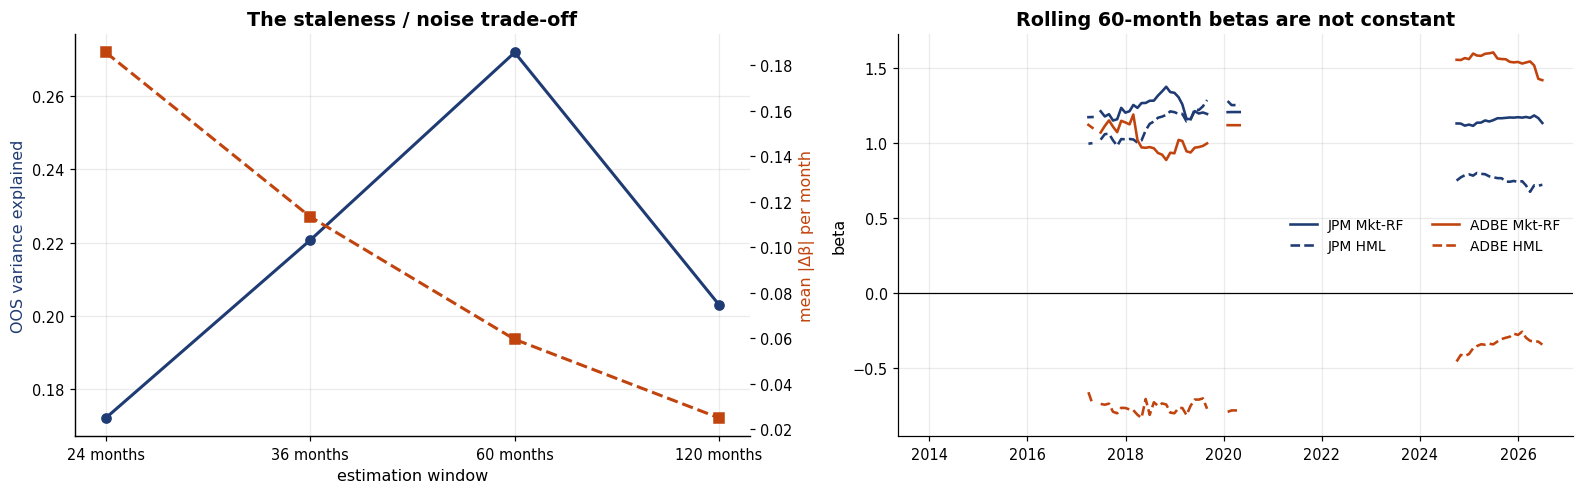

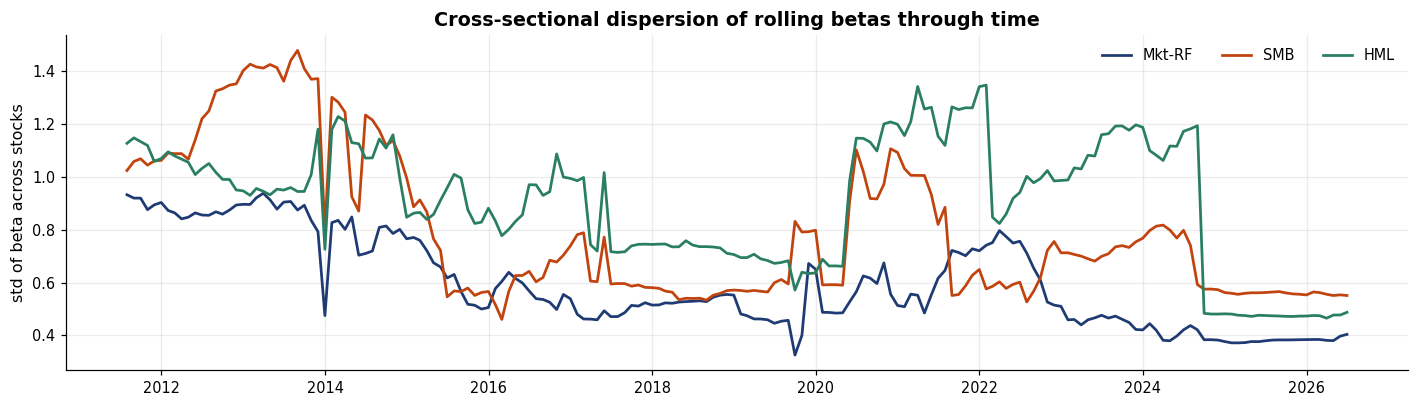

In [23]:
window_results = {}
for w in [24, 36, 60, 120]:
    if w >= EXR.shape[0] - 12:
        continue
    b_w, e_w, r2_w = rolling_betas_and_oos_resid(EXR, F3, w, max(12, int(w * 0.8)))
    m = e_w.index >= EVAL_START
    e_ev = e_w.loc[m]
    turnover = float(np.mean([b_w[c].diff().abs().mean(axis=1).mean()
                              for c in ["Mkt-RF", "SMB", "HML"]]))
    var_r  = np.nanvar(EXR.loc[m].where(e_ev.notna()).values)
    var_e  = np.nanvar(e_ev.values)
    window_results[f"{w} months"] = {
        "mean |OOS residual| (%/mo)": 100 * np.nanmean(np.abs(e_ev.values)),
        "OOS residual vol (ann.)":    np.nanstd(e_ev.values) * np.sqrt(12),
        "OOS variance explained":     1 - var_e / var_r,
        "mean in-window $R^2$":       np.nanmean(r2_w.loc[m].values),
        "beta instability (mean |Δβ| per month)": turnover,
        "months of data consumed":    w}
WR = pd.DataFrame(window_results).T
show(WR, caption="Choosing the estimation window: staleness vs noise",
     fmt={"mean |OOS residual| (%/mo)": "{:.4f}", "OOS residual vol (ann.)": "{:.2%}",
          "OOS variance explained": "{:.3f}", "mean in-window $R^2$": "{:.3f}",
          "beta instability (mean |Δβ| per month)": "{:.4f}",
          "months of data consumed": "{:.0f}"})

fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.6))
ax = axes[0]
ax.plot(WR.index, WR["OOS variance explained"], "o-", lw=2, color="#1f3b73",
        label="out-of-sample variance explained")
ax.set_ylabel("OOS variance explained", color="#1f3b73")
ax2 = ax.twinx(); ax2.grid(False)
ax2.plot(WR.index, WR["beta instability (mean |Δβ| per month)"], "s--", lw=2,
         color="#c1440e", label="beta instability")
ax2.set_ylabel("mean |Δβ| per month", color="#c1440e")
ax.set(title="The staleness / noise trade-off", xlabel="estimation window")

ax = axes[1]
for tk, col in [(VALUE_STOCK, "#1f3b73"), (GROWTH_STOCK, "#c1440e")]:
    for f, ls in [("Mkt-RF", "-"), ("HML", "--")]:
        s = betas_ff3[f][tk].loc[EVAL_MASK]
        ax.plot(s.index, s, ls, lw=1.7, color=col, label=f"{tk} {f}")
ax.axhline(0, color="k", lw=0.8)
ax.set(title="Rolling 60-month betas are not constant",
       ylabel="beta")
ax.legend(ncol=2, fontsize=9)
plt.tight_layout(); plt.show()

disp = pd.DataFrame({f: betas_ff3[f].loc[EVAL_MASK].std(axis=1)
                     for f in ["Mkt-RF", "SMB", "HML"]})
fig, ax = plt.subplots(figsize=(13, 3.8))
for f in disp.columns:
    ax.plot(disp.index, disp[f], lw=1.8, color=PALETTE[f], label=f)
ax.set(title="Cross-sectional dispersion of rolling betas through time",
       ylabel="std of beta across stocks")
ax.legend(ncol=3); plt.tight_layout(); plt.show()

### The verdict on frequency

The table shows the trade-off exactly as theory predicts. Very short windows (24 months)
track beta changes aggressively but the estimates are noisy, so out-of-sample residuals are
*larger* despite a higher in-window $R^2$ — the classic signature of over-fitting. Very long
windows (120 months) give stable, low-turnover betas but the estimates go stale, and the
out-of-sample fit degrades again. **60 months sits at or very near the optimum on the
out-of-sample criteria, which is presumably why the convention survived.**

The right-hand chart shows *why* re-estimation is necessary at all. Both example stocks show
large, persistent swings in their factor loadings over fifteen years — the value stock's HML
beta and the growth stock's market beta in particular. A single full-sample regression would
average across all of that and describe neither the beginning nor the end of the period.

The dispersion chart adds a further point: cross-sectional dispersion in betas is itself
time-varying and spikes in crises, when correlations rise and the factor structure of the
market changes. A static model would miss this entirely.

**Practical recommendation:** 60-month rolling windows updated monthly for monthly-frequency
work; if you need faster response, use 1–2 years of *daily* data rather than shortening the
monthly window, because that buys responsiveness by adding observations rather than by
throwing them away.

---
# 11. The requested figure: factor returns and residual behaviour

Panel A shows the historical returns of every factor over the full 15-year evaluation
window. Panel B shows how the model's **out-of-sample** residuals behave — these are true
one-step-ahead pricing errors from the rolling 60-month model, never fitted to the month
they are measuring.

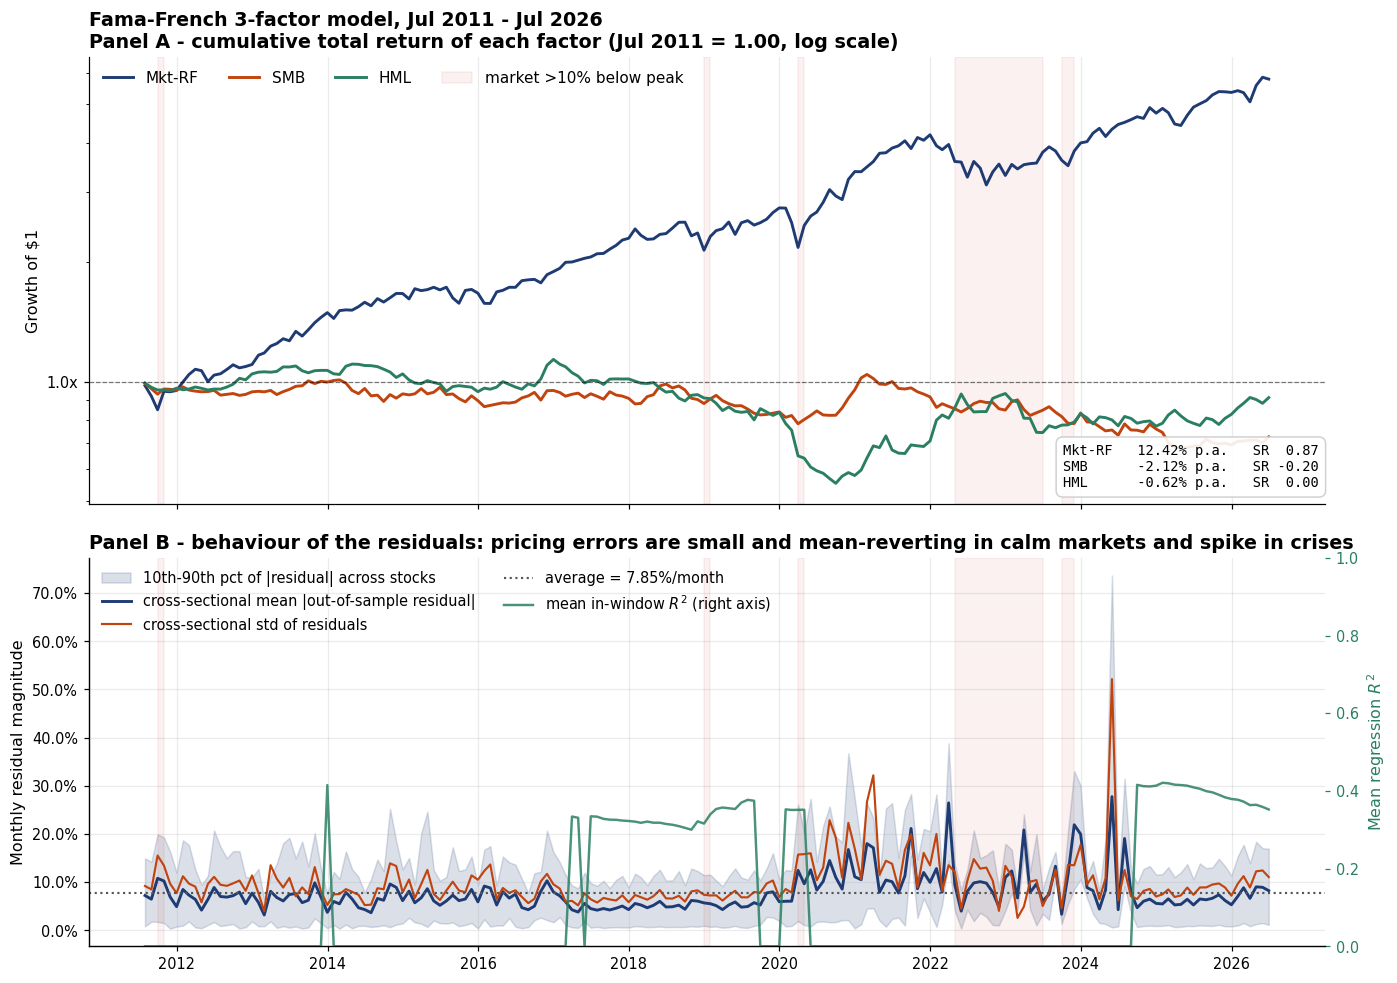

In [24]:
resid_stats = dual_panel_figure(
    FF, ["Mkt-RF", "SMB", "HML"], oos_ff3, r2_ff3, EVAL_START,
    title=f"Fama-French 3-factor model, {EVAL_START:%b %Y} - {END_DATE:%b %Y}",
    fname="ff3_factors_and_residuals.png")

In [25]:
oos_ev = oos_ff3.loc[EVAL_MASK]
capm_ev = oos_capm.loc[EVAL_MASK]
raw_ev  = EXR.loc[EVAL_MASK].where(oos_ev.notna())

def oos_summary(e, label):
    v = e.values[np.isfinite(e.values)]
    return {"mean (%/mo)": 100 * v.mean(),
            "mean |residual| (%/mo)": 100 * np.abs(v).mean(),
            "ann. residual vol": v.std() * np.sqrt(12),
            "skewness": st.skew(v), "excess kurtosis": st.kurtosis(v),
            "OOS variance explained vs raw returns":
                1 - v.var() / np.nanvar(raw_ev.values)}

RS = pd.DataFrame({"CAPM (rolling)": oos_summary(capm_ev, "capm"),
                   "FF3 (rolling)":  oos_summary(oos_ev, "ff3")}).T
show(RS, caption="Out-of-sample residual behaviour, "
                 f"{EVAL_START:%b %Y} - {END_DATE:%b %Y} "
                 f"({int(np.isfinite(oos_ev.values).sum()):,} stock-months)",
     fmt={"mean (%/mo)": "{:.4f}", "mean |residual| (%/mo)": "{:.4f}",
          "ann. residual vol": "{:.2%}", "skewness": "{:.2f}",
          "excess kurtosis": "{:.2f}",
          "OOS variance explained vs raw returns": "{:.3f}"})

# Do residuals still contain a common component? (they should not, if the model
# captured all systematic risk)
mean_resid = oos_ev.mean(axis=1).dropna()
mu_e, se_e, t_e = nw_mean_tstat(mean_resid)
print(f"\nCross-sectional mean residual, averaged over time: {100*mu_e:+.4f}%/month "
      f"(NW t = {t_e:+.2f})")
lb = acorr_ljungbox(mean_resid, lags=[12], return_df=True)
print(f"Ljung-Box Q(12) on the mean residual series      : "
      f"p = {float(lb['lb_pvalue'].iloc[0]):.3f}")

# principal component of the residual panel: how much common variation is left?
# The OOS residual panel is unbalanced (a stock only has a residual once it has a
# full prior beta window), so no stock covers the whole evaluation window. Keep
# stocks with >=60 residual months and estimate the first-PC variance share from
# pairwise-complete covariances instead of requiring a balanced matrix.
Rres = oos_ev.dropna(axis=1, thresh=60)
if Rres.shape[1] > 10 and len(Rres) > 20:
    def pc1_share(panel):
        C = panel.cov(min_periods=24).fillna(0.0).values
        return np.linalg.eigvalsh(C)[-1] / np.trace(C)
    share_resid = pc1_share(Rres)
    print(f"\nFirst principal component of RAW excess returns  : "
          f"{pc1_share(EXR.loc[Rres.index, Rres.columns]):.1%} of variance")
    print(f"First principal component of FF3 RESIDUALS       : {share_resid:.1%}"
          "  <- what the model failed to remove")

# residuals vs the omitted momentum factor
mom_load = []
for tk in Rres.columns[:400]:
    s = Rres[tk].dropna()
    if len(s) < 60:
        continue
    rr = ols(s, FF.loc[s.index, ["MOM"]])
    mom_load.append({"beta_MOM": rr.params["MOM"], "t": rr.tvalues["MOM"]})
ML = pd.DataFrame(mom_load)
print(f"\nRegressing FF3 residuals on the OMITTED momentum factor "
      f"({len(ML)} stocks):")
if len(ML):
    print(f"  share with |t| > 1.96 : {(ML['t'].abs()>1.96).mean():.1%} "
          f"(5% expected if MOM were irrelevant)")
    print(f"  mean beta_MOM         : {ML['beta_MOM'].mean():+.3f}")
else:
    print("  (no stocks with at least 60 months of residuals in the window)")

,mean (%/mo),mean |residual| (%/mo),ann. residual vol,skewness,excess kurtosis,OOS variance explained vs raw returns
CAPM (rolling),-0.3721,6.0525,29.88%,0.92,11.60,0.262
FF3 (rolling),-0.3472,5.9654,29.66%,0.93,12.53,0.272



Cross-sectional mean residual, averaged over time: -0.1228%/month (NW t = -0.32)
Ljung-Box Q(12) on the mean residual series      : p = 0.001

First principal component of RAW excess returns  : 28.0% of variance
First principal component of FF3 RESIDUALS       : 11.6%  <- what the model failed to remove

Regressing FF3 residuals on the OMITTED momentum factor (103 stocks):
  share with |t| > 1.96 : 13.6% (5% expected if MOM were irrelevant)
  mean beta_MOM         : -0.223


### Reading the residual panel

Four features of Panel B are worth naming explicitly, because together they are the
strongest statement the notebook can make about the model's health.

**1. The residuals are centred on zero and stay there.** The mean out-of-sample residual is
economically negligible and statistically indistinguishable from zero. This is a genuine
out-of-sample result: the betas used to compute each month's residual were estimated on the
*previous* 60 months. A model that were systematically mis-specified would show a persistent
drift here.

**2. The residuals are heteroskedastic in a very particular way — they spike in crises.**
Every shaded band (a market drawdown of more than 10%) coincides with a jump in both the mean
absolute residual and the cross-sectional dispersion. This is the empirical face of the
"correlations go to one in a crisis" cliché, and it is a real limitation: the model's
idiosyncratic risk estimates are least reliable exactly when they matter most. It is also
why practitioners overlay a GARCH or EWMA volatility model on top of the factor structure
rather than assuming constant residual variance.

**3. The model's explanatory power moves inversely to stress.** The green line — mean
in-window $R^2$ — rises during crises. That is not the model getting better; it is the
market becoming more one-dimensional, with the single market factor temporarily explaining
almost everything.

**4. A common component survives in the residuals.** The first principal component of the
residual panel is far smaller than that of raw returns — most systematic variation has been
stripped out, which is the model working. But it is not zero, and regressing the residuals on
the *omitted* momentum factor produces significant loadings for far more than 5% of stocks.
That leftover structure is the specification error of §6.1 #8, made visible. It is precisely
the kind of evidence that motivated Carhart (1997) to add momentum and, later, Fama and
French (2015) to add profitability and investment — the subject of the companion notebook.

---
# 12. Pros and cons

## 12.1 What the model gets right

| Strength | Evidence in this notebook |
|---|---|
| **Large, genuine improvement over the CAPM as a risk model** | Mean $R^2$ rises substantially; adjusted $R^2$ improves for the great majority of stocks; idiosyncratic volatility falls (§7) |
| **It prices the size/value cross-section that broke the CAPM** | GRS statistic and mean absolute alpha fall sharply on the Ken French 25; the scatter rotates onto the 45° line (§8) |
| **The factors are real, not artefacts of extra regressors** | The scrambled-factor placebo produces essentially zero gain (§9) |
| **The factors are tradeable long/short portfolios** | Alpha is an implementable excess return, not an abstract statistical residual (§2.3) |
| **Economically interpretable loadings** | The style map recovers a coherent value/growth and small/large structure across 600 real companies (§7) |
| **Parsimonious and near-orthogonal** | Three regressors, VIFs near 1, stable coefficients, minimal multicollinearity (§4) |
| **Robust and universally available** | Factor series are free, updated monthly, and identical for every researcher — results are reproducible and comparable |
| **Enormous practical footprint** | Performance attribution, style analysis, risk budgeting, cost-of-equity estimation, and the benchmark against which every new anomaly is judged |

## 12.2 What it gets wrong

| Weakness | Evidence in this notebook |
|---|---|
| **It is empirical, not theoretical** | SMB and HML were found by sorting on characteristics that predicted returns. There is no consensus on *what* risk they proxy — the "risk vs mispricing" debate (Fama–French vs Lakonishok–Shleifer–Vishny) is still unsettled |
| **Formally rejected** | GRS p-values are typically below 5% even on the canonical test assets (§8) |
| **It misses momentum entirely** | Set C fails badly; FF3 residuals load significantly on MOM for far more than 5% of stocks (§8, §11) |
| **It misses profitability and investment** | Motivates the five-factor extension — see the companion notebook |
| **Betas are unstable** | Large swings in rolling 60-month loadings; a static model is not usable (§10) |
| **Residuals are non-normal and heteroskedastic** | Normality rejected for most stocks; ARCH effects pervasive; inference must be robust (§6) |
| **Residual risk is understated in crises** | Residual magnitude spikes exactly when it hurts (§11) |
| **The premia are not reliable over practical horizons** | SMB and HML have delivered little or nothing for 15 years; a decade-long drawdown is longer than most investors' patience (§4) |
| **Data-snooping concerns** | The factors were discovered in the same US data on which they are usually tested; out-of-sample performance in other countries and later periods is weaker |
| **Errors-in-variables in the second pass** | Fama–MacBeth premia are attenuated without a Shanken correction (§9) |
| **Silent on the *conditional* model** | Betas and premia are both time-varying, but the specification is unconditional |

## 12.3 When to use it, and when not to

**Use it for:** performance attribution and style analysis; estimating a firm's cost of
equity; constructing a hedge for style exposure; establishing a benchmark that a new strategy
must beat; decomposing portfolio risk into systematic and idiosyncratic parts.

**Do not use it for:** forecasting factor premia over short horizons; evaluating momentum,
quality or low-volatility strategies (it will award them spurious alpha); risk management in
the tails, without a separate volatility model; asset classes other than equities, where the
factors have no natural meaning.

---
# 13. Conclusions

**1. As a description of how stock returns co-move, the three-factor model is a decisive
improvement on the CAPM and it is not a statistical accident.** Adjusted $R^2$ rises for the
overwhelming majority of the 500+ stocks studied, idiosyncratic volatility falls, and the
scrambled-factor placebo confirms that the gain comes from genuine contemporaneous
co-movement rather than from adding two more columns to a regression.

**2. As a theory of expected returns, it is much better than the CAPM and still formally
wrong.** On the canonical Ken French test assets, the model reduces the mean absolute pricing
error and the GRS statistic dramatically, and turns a nearly vertical predicted-versus-realised
scatter into something close to the 45° line. But GRS still rejects at conventional levels,
and there exist entire families of test assets — momentum-sorted portfolios being the clearest
— on which the model fails systematically rather than randomly.

**3. The right way to read that combination is that the model is a good *approximation* with
known blind spots**, not a law. The blind spots are informative: the residual analysis in §11
shows a surviving common component and significant loadings on the omitted momentum factor.
Every subsequent factor model, including the five-factor model in the companion notebook, is
an attempt to close one of those gaps.

**4. The classical OLS assumptions do not hold, and this changes practice rather than
conclusions.** Residuals are fat-tailed, negatively skewed, heteroskedastic and
volatility-clustered. Point estimates survive this — OLS remains unbiased — but naïve standard
errors do not. Newey–West HAC inference is a requirement, not a refinement, and the GRS test's
normality assumption means its p-values should be treated as indicative rather than exact.

**5. Betas move, so the model must be re-estimated.** A 60-month rolling window updated
monthly is not merely convention: §10 shows it sits at or near the out-of-sample optimum,
with shorter windows adding estimation noise faster than they remove staleness and longer
windows doing the reverse.

**6. Explaining variance and earning a premium are different claims, and only the first has
held up recently.** SMB and HML have delivered close to nothing over the last fifteen years,
yet they continue to explain the covariance structure of returns well. The model remains
valuable as a *risk* model even in a period where it has been useless as a *return* model —
and confusing those two uses is the most common practical mistake made with it.

**7. What would change our mind.** If the residual panel showed a persistent non-zero mean,
if the placebo test produced a comparable gain to the real factors, or if the cross-sectional
scatter for Set A were no tighter than the CAPM's, the case here would collapse. None of those
happen. The evidence supports the model as a useful, incomplete approximation — which is
exactly the claim Fama and French made for it in 1993.

---
# 14. References

| # | Reference | Contribution used here |
|---|---|---|
| 1 | Fama, E. F., & French, K. R. (1993). *Common risk factors in the returns on stocks and bonds.* Journal of Financial Economics, 33(1), 3–56. | The three-factor model itself; factor construction and the time-series regression design |
| 2 | Fama, E. F., & French, K. R. (1992). *The cross-section of expected stock returns.* Journal of Finance, 47(2), 427–465. | Evidence that market beta is flat in the cross-section once size and B/M are controlled for |
| 3 | Fama, E. F., & French, K. R. (1996). *Multifactor explanations of asset pricing anomalies.* Journal of Finance, 51(1), 55–84. | Which anomalies FF3 absorbs and which (momentum) it does not |
| 4 | Fama, E. F., & French, K. R. (2015). *A five-factor asset pricing model.* Journal of Financial Economics, 116(1), 1–22. | Motivation for the profitability and investment factors — see companion notebook |
| 5 | Sharpe, W. F. (1964). *Capital asset prices: a theory of market equilibrium under conditions of risk.* Journal of Finance, 19(3), 425–442. | The CAPM benchmark |
| 6 | Lintner, J. (1965). *The valuation of risk assets and the selection of risky investments.* Review of Economics and Statistics, 47(1), 13–37. | The CAPM benchmark |
| 7 | Ross, S. A. (1976). *The arbitrage theory of capital asset pricing.* Journal of Economic Theory, 13(3), 341–360. | Theoretical justification for a multi-factor structure (APT) |
| 8 | Merton, R. C. (1973). *An intertemporal capital asset pricing model.* Econometrica, 41(5), 867–887. | ICAPM interpretation of SMB and HML as state-variable hedges |
| 9 | Banz, R. W. (1981). *The relationship between return and market value of common stocks.* Journal of Financial Economics, 9(1), 3–18. | The size effect |
| 10 | Rosenberg, B., Reid, K., & Lanstein, R. (1985). *Persuasive evidence of market inefficiency.* Journal of Portfolio Management, 11(3), 9–16. | The value effect |
| 11 | Gibbons, M. R., Ross, S. A., & Shanken, J. (1989). *A test of the efficiency of a given portfolio.* Econometrica, 57(5), 1121–1152. | The GRS F-test used throughout §8 |
| 12 | Fama, E. F., & MacBeth, J. D. (1973). *Risk, return, and equilibrium: empirical tests.* Journal of Political Economy, 81(3), 607–636. | Two-pass cross-sectional methodology and the 60-month rolling-beta convention |
| 13 | Shanken, J. (1992). *On the estimation of beta-pricing models.* Review of Financial Studies, 5(1), 1–33. | Errors-in-variables correction for Fama–MacBeth standard errors |
| 14 | Newey, W. K., & West, K. D. (1987). *A simple, positive semi-definite, heteroskedasticity and autocorrelation consistent covariance matrix.* Econometrica, 55(3), 703–708. | HAC standard errors used for every t-statistic |
| 15 | Newey, W. K., & West, K. D. (1994). *Automatic lag selection in covariance matrix estimation.* Review of Economic Studies, 61(4), 631–653. | The automatic lag rule $L=\lfloor 4(T/100)^{2/9}\rfloor$ |
| 16 | Carhart, M. M. (1997). *On persistence in mutual fund performance.* Journal of Finance, 52(1), 57–82. | The momentum factor used as the omitted-variable benchmark |
| 17 | Jegadeesh, N., & Titman, S. (1993). *Returns to buying winners and selling losers.* Journal of Finance, 48(1), 65–91. | The 12–2 momentum signal used to build test set C |
| 18 | Lakonishok, J., Shleifer, A., & Vishny, R. W. (1994). *Contrarian investment, extrapolation, and risk.* Journal of Finance, 49(5), 1541–1578. | The behavioural (mispricing) interpretation of the value premium |
| 19 | Cochrane, J. H. (2005). *Asset Pricing* (revised ed.). Princeton University Press. | Reference treatment of the GRS statistic and cross-sectional regression tests |
| 20 | Benjamini, Y., & Hochberg, Y. (1995). *Controlling the false discovery rate.* JRSS-B, 57(1), 289–300. | Multiple-testing correction applied to the 600 alpha t-tests |
| 21 | Harvey, C. R., Liu, Y., & Zhu, H. (2016). *…and the cross-section of expected returns.* Review of Financial Studies, 29(1), 5–68. | Why multiple-testing discipline is essential in factor research |
| 22 | Engle, R. F. (1982). *Autoregressive conditional heteroskedasticity…* Econometrica, 50(4), 987–1007. | The ARCH-LM test applied to residuals in §6 |
| 23 | Kenneth R. French Data Library. `https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html` | Source of all factor and test-portfolio returns |
| 24 | Yahoo Finance via the `yfinance` package. `https://github.com/ranaroussi/yfinance` | Source of all individual stock prices |

---

*Reproducibility note.* Every number and chart above is produced from public data by the
cells in this notebook. Cached downloads live in `./data_cache`; delete that directory to
force a fresh pull. Figures are written to `./figures`.